In [1]:
import pandas as pd
import glob as glob
from Bio.Seq import Seq
import os
import numpy as np
from Bio import motifs
from matplotlib import pyplot as plt
from utils import draw_tf_heatmap , annotate_region
import dask.dataframe as dd
import importlib
import utils
from utils import draw_tf_heatmap , annotate_region


In [2]:
data_test='cisbp'
inputfolder = '/data2st2/junyi/output/atac1112/tobiasbam/'

In [3]:
files =glob.glob('/data2st1/junyi/scenic/mouse/motif/singletons/*')
outdir = '/data2st1/junyi/scenic/mouse/motif/merged_cluster'
tbffile = '/data2st1/junyi/scenic/mouse/motif/motifs-v10nr_clust-nr.mgi-m0.001-o0.0.tbl'
TFoutdir = '/data2st1/junyi/output/atac1112/snregulation/'
df_important_TF = pd.read_csv(f'/data2st2/junyi/output/stg1028/CUMS_4VN/scenicwil_tfs_fdr_log2fc0/significant_TFlist.csv',header=None)
df_important_TF.columns=['TF']
df_tbffile = pd.read_csv(tbffile, sep='\t')

/tmp/ipykernel_1129484/4282565885.py:7: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df_tbffile = pd.read_csv(tbffile, sep='\t')


In [4]:
df = df_tbffile
motif_similarity_fdr = 0.001,
orthologous_identity_threshold  = 0.0
df.rename(columns={'#motif_id':"MotifID",
                    'gene_name':"TF",
                    'motif_similarity_qvalue': "MotifSimilarityQvalue",
                    'orthologous_identity': "OrthologousIdentity",
                    'description': "Annotation" }, inplace=True)
df = df[(df["MotifSimilarityQvalue"] <= motif_similarity_fdr) &
        (df["OrthologousIdentity"] >= orthologous_identity_threshold)]


In [5]:
df_direct_annot = df[df['Annotation'] == 'gene is directly annotated']
#df_direct_annot = df_direct_annot.groupby(['MotifID'])['TF'].apply(lambda x: ', '.join(list(set(x)))).reset_index()

df_direct_annot.to_csv(os.path.join(outdir, 'motif_TF_annotated.tsv'), index=False)
df_direct_annot['soure_name'] = df_direct_annot['source_name']+"__"+df_direct_annot['motif_name']
df_direct_annot['TFBS_name'] = df_direct_annot['MotifID'] +  df_direct_annot['soure_name'] + "_None"
dict_id2tf = dict(zip(df_direct_annot['soure_name'], df_direct_annot['TF']))
motif_similarity_annot = df[df['Annotation'].str.contains('similar') & ~df['Annotation'].str.contains('orthologous')]
#motif_similarity_annot = motif_similarity_annot.groupby(['MotifID'])['TF'].apply(lambda x: ', '.join(list(set(x)))).reset_index()

direct_motif_TFs = df_direct_annot[df_direct_annot.TF.isin(df_important_TF.TF)]
direct_motif_TFs = direct_motif_TFs.groupby(['MotifID'])['TF'].apply(lambda x: ', '.join(list(set(x)))).reset_index()


/tmp/ipykernel_1129484/747042444.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_direct_annot['soure_name'] = df_direct_annot['source_name']+"__"+df_direct_annot['motif_name']
/tmp/ipykernel_1129484/747042444.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_direct_annot['TFBS_name'] = df_direct_annot['MotifID'] +  df_direct_annot['soure_name'] + "_None"


In [6]:
# direct_motifs = []
# names = []
# parsed_TFs= []
# for f in files:
#     bn = os.path.basename(f).removesuffix('.cb')
#     if bn not in direct_motif_TFs['MotifID'].values:
#         #print(f"Skipping {bn} as it is not in the important TF list.")
#         continue
#     tf_tmp = direct_motif_TFs[direct_motif_TFs['MotifID'] == bn].TF.values[0]
#     try:
#         with open(f) as handle:
#             m = motifs.read(handle, "ClusterBuster")
#             direct_motifs.append(m)
#             names.append(bn)
#             parsed_TFs.append(tf_tmp)
#             if 'MA0859.1' in record.name:
#                 print("here")

#     except ValueError:
#         with open(f) as handle:
#             records = motifs.parse(handle, "ClusterBuster")
#             for record in records:
#                 if 'MA0859.1' in record.name:
#                     print("here")
#                 record.name = bn+"#"+record.name
#                 direct_motifs.append(record)
#                 names.append(record.name)
#                 parsed_TFs.append(tf_tmp)

# mapdict = dict(zip(names, parsed_TFs))

In [7]:
extended_motif_TFs = motif_similarity_annot[motif_similarity_annot.TF.isin(df_important_TF.TF)]
extended_motif_TFs = extended_motif_TFs.groupby(['MotifID'])['TF'].apply(lambda x: ', '.join(list(set(x)))).reset_index()

In [8]:
TOBIAS_Rsults = glob.glob(f'{inputfolder}/*{data_test}*/*.bw/bindetect_results.xlsx')

# Merge all TOBIAS results on TF level

In [16]:
%%capture
# ignore cell outputs for this cell
results = pd.DataFrame()
full = pd.DataFrame()
full_results = pd.DataFrame()
for file in TOBIAS_Rsults:
    print(file)
    df_tobias = pd.read_excel(file)
    ctname = file.split('/')[-2].replace('_MC_footprints.bw','')
    region = ctname[:3]
    df_tobias['ctname'] = ctname
    df_tobias['MotifID'] = df_tobias['name'].str.split('#').str[0]
    df_tobias['source_name'] = df_tobias['name'].str.split('#').str[1]
    df_tobias['TF']=df_tobias['source_name'].map(dict_id2tf)
    df_tobias.dropna(inplace=True)
    df_tobias['abs_change'] = df_tobias['MC_MW_change'].abs()
    #df_tobias.sort_values(by='abs_change', ascending=False, inplace=True)
    #df_tobias.drop_duplicates(subset=['TFID','TF'], inplace=True)
    # df_tobias["TFexpand"] = df_tobias["TF"].str.split(",\s*")  # split by comma + optional space
    # df_expanded = df_tobias.explode("TFexpand").reset_index(drop=True)
    full_results = pd.concat([full_results, df_tobias], axis=0)
    #results = pd.concat([results, df_expanded_mean], axis=0)

# Vizualize the results as heatmap

In [17]:
def add_columns(results):
    if 'MC_MW_change' in results.columns:
        results['Direction'] = results['MC_MW_change'].apply(lambda x: 'Up' if x > 0 else 'Down')
        results['log2FC'] = results['MC_MW_change']
    elif 'log2FC_Weighted' in results.columns:
        results['Direction'] = results['log2FC_Weighted'].apply(lambda x: 'Up' if x > 0 else 'Down')
    results['Sex'] = 'M'
    results['Gene'] = results['TF']
    if 'ctname' in results.columns:
        results['ctname'] = results['ctname'].str.replace('HIP','HPF')
    results["Neurotransmitter"] =  results["ctname"].apply(lambda x: 'Glut' if 'Glut' in x else ('GABA' if 'GABA' in x else 'NN'))
    results['Region Subclass'] = results['ctname']
    if ('FDR' not in results.columns) and ('MC_MW_pvalue' in results.columns):
        results['FDR'] = results['MC_MW_pvalue']
    results['Subclass'] = results['Region Subclass'].str[4:].replace('HIP','HPF')
    if 'Region' not in results.columns:
        results['Region'] = results['Region Subclass'].str[:3]
    results['Region'] = results['Region'].str.replace('HIP','HPF')
    results['status'] = results['Direction']
    results['celltype.L2'] = results['Subclass']
    return results


In [19]:
full_results = add_columns(full_results)
#avg_results = add_columns(results)
#full_results_filtered = full_results[full_results['MC_MW_highlighted']==True]
# full_results_filtered = full_results[full_results.FDR < 0.05]
# full_results_filtered['absLog2FC'] = full_results_filtered['log2FC'].abs()
# full_results_filtered.sort_values(by=['absLog2FC','total_tfbs'], ascending=[False, False], inplace=True)
# full_results_filtered.drop_duplicates(subset=['TF','Region Subclass','status'], inplace=True)
#results=avg_results[avg_results.FDR <0.05]
results=full_results[full_results.FDR < 0.05]
results['nlogp'] = -np.log10(results['FDR'] + 1e-300) * np.sign(results['log2FC'])
results['Regulation'] = results['MC_MW_change'].apply(lambda x: 1 if x > 0 else -1)
results['Regulation']=results['Regulation'].astype(float)

/tmp/ipykernel_1129484/971198905.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results['nlogp'] = -np.log10(results['FDR'] + 1e-300) * np.sign(results['log2FC'])
/tmp/ipykernel_1129484/971198905.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results['Regulation'] = results['MC_MW_change'].apply(lambda x: 1 if x > 0 else -1)
/tmp/ipykernel_1129484/971198905.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] =

In [20]:
results

,output_prefix,name,motif_id,cluster,total_tfbs,MC_mean_score,MC_bound,MW_mean_score,MW_bound,MC_MW_change,...,Gene,Neurotransmitter,Region Subclass,FDR,Subclass,Region,status,celltype.L2,nlogp,Regulation
0,metacluster_121.1cisbp__M00811_None,metacluster_121.1#cisbp__M00811,None,C_metacluster_121.1#cisbp__M02401,14201,0.37210,2642,0.35981,2353,0.05662,...,Nr2f6,GABA,HPF_HPF_Sst_GABA,8.520190e-85,HPF_Sst_GABA,HPF,Up,HPF_Sst_GABA,84.069551,1.0
1,metacluster_121.1cisbp__M00812_None,metacluster_121.1#cisbp__M00812,None,C_metacluster_121.1#cisbp__M02401,14379,0.38274,2769,0.36897,2480,0.05952,...,Nr2c1,GABA,HPF_HPF_Sst_GABA,3.912670e-90,HPF_Sst_GABA,HPF,Up,HPF_Sst_GABA,89.407527,1.0
2,metacluster_121.1cisbp__M00820_None,metacluster_121.1#cisbp__M00820,None,C_metacluster_121.1#cisbp__M00820,10037,0.42342,2329,0.41329,2105,0.06037,...,Rorb,GABA,HPF_HPF_Sst_GABA,3.733430e-86,HPF_Sst_GABA,HPF,Up,HPF_Sst_GABA,85.427892,1.0
3,metacluster_121.1cisbp__M01297_None,metacluster_121.1#cisbp__M01297,None,C_metacluster_121.1#cisbp__M01297,10956,0.36931,2040,0.35638,1798,0.06335,...,Esr2,GABA,HPF_HPF_Sst_GABA,1.852130e-80,HPF_Sst_GABA,HPF,Up,HPF_Sst_GABA,79.732329,1.0
4,metacluster_121.1cisbp__M02399_None,metacluster_121.1#cisbp__M02399,None,C_metacluster_121.1#cisbp__M02401,11159,0.36659,2022,0.35084,1757,0.07162,...,Nr2c1,GABA,HPF_HPF_Sst_GABA,3.086070e-92,HPF_Sst_GABA,HPF,Up,HPF_Sst_GABA,91.510594,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
343,metacluster_181.1transfac_public__M00450_None,metacluster_181.1#transfac_public__M00450,None,C_metacluster_181.1#transfac_public__M00450,12590,0.52797,3941,0.56583,4319,-0.02594,...,Zic3,NN,AMY_MOL-2,4.536660e-49,MOL-2,AMY,Down,MOL-2,-48.343264,-1.0
344,metacluster_181.1cisbp__M01022_None,metacluster_181.1#cisbp__M01022,None,C_metacluster_181.1#cisbp__M01022,13935,0.55294,4397,0.59410,4837,-0.03531,...,Gli3,NN,AMY_MOL-2,9.116130e-66,MOL-2,AMY,Down,MOL-2,-65.040189,-1.0
345,metacluster_181.1cisbp__M01023_None,metacluster_181.1#cisbp__M01023,None,C_metacluster_181.1#cisbp__M01022,13903,0.56830,4523,0.61087,4979,-0.03418,...,Gli1,NN,AMY_MOL-2,8.026800e-60,MOL-2,AMY,Down,MOL-2,-59.095458,-1.0
346,metacluster_181.1cisbp__M01024_None,metacluster_181.1#cisbp__M01024,None,C_metacluster_181.1#cisbp__M01022,14168,0.53413,4427,0.57388,4859,-0.03519,...,Gli2,NN,AMY_MOL-2,3.858280e-63,MOL-2,AMY,Down,MOL-2,-62.413606,-1.0


Checking columns...
Constant columns: []
Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..


/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


Starting plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 39.68888888888889 mm


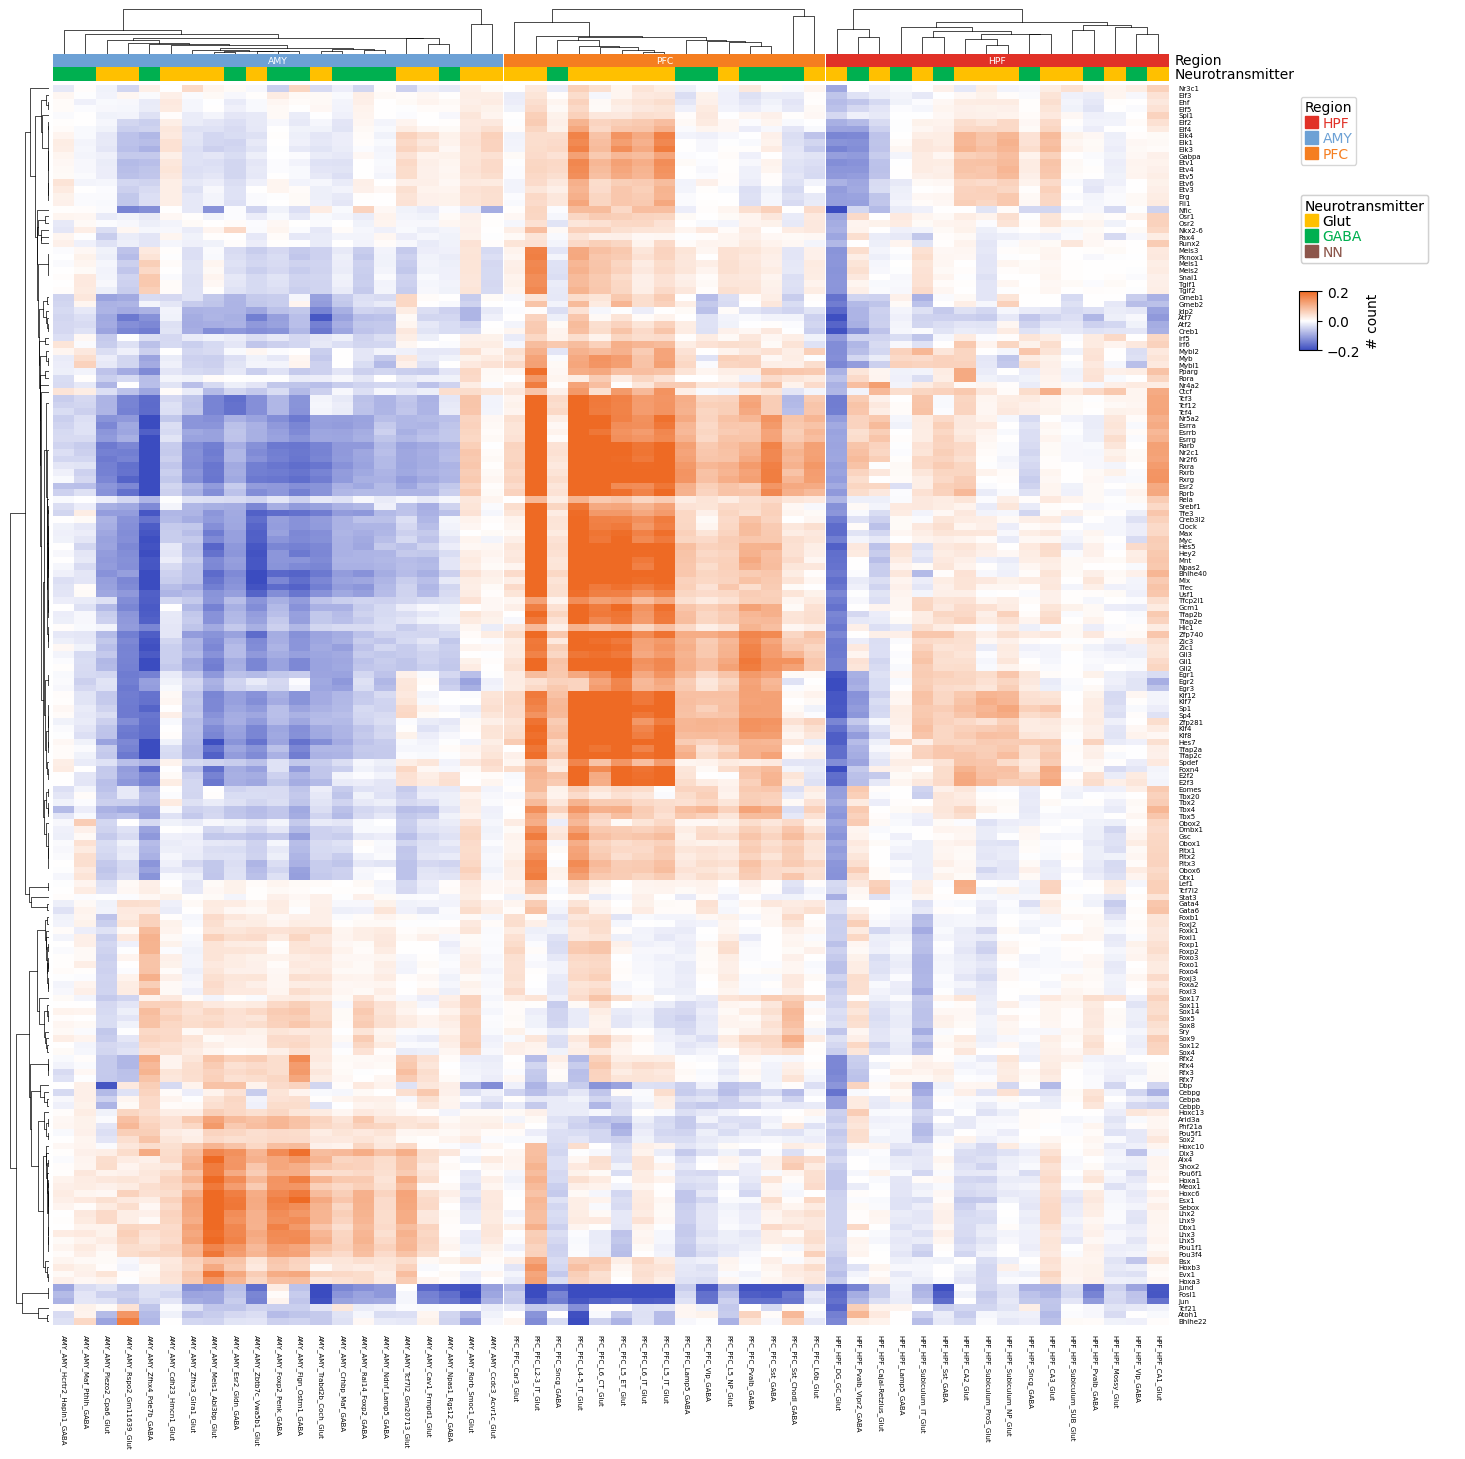

Checking columns...
Constant columns: []
Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..


/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


Starting plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 39.68888888888889 mm


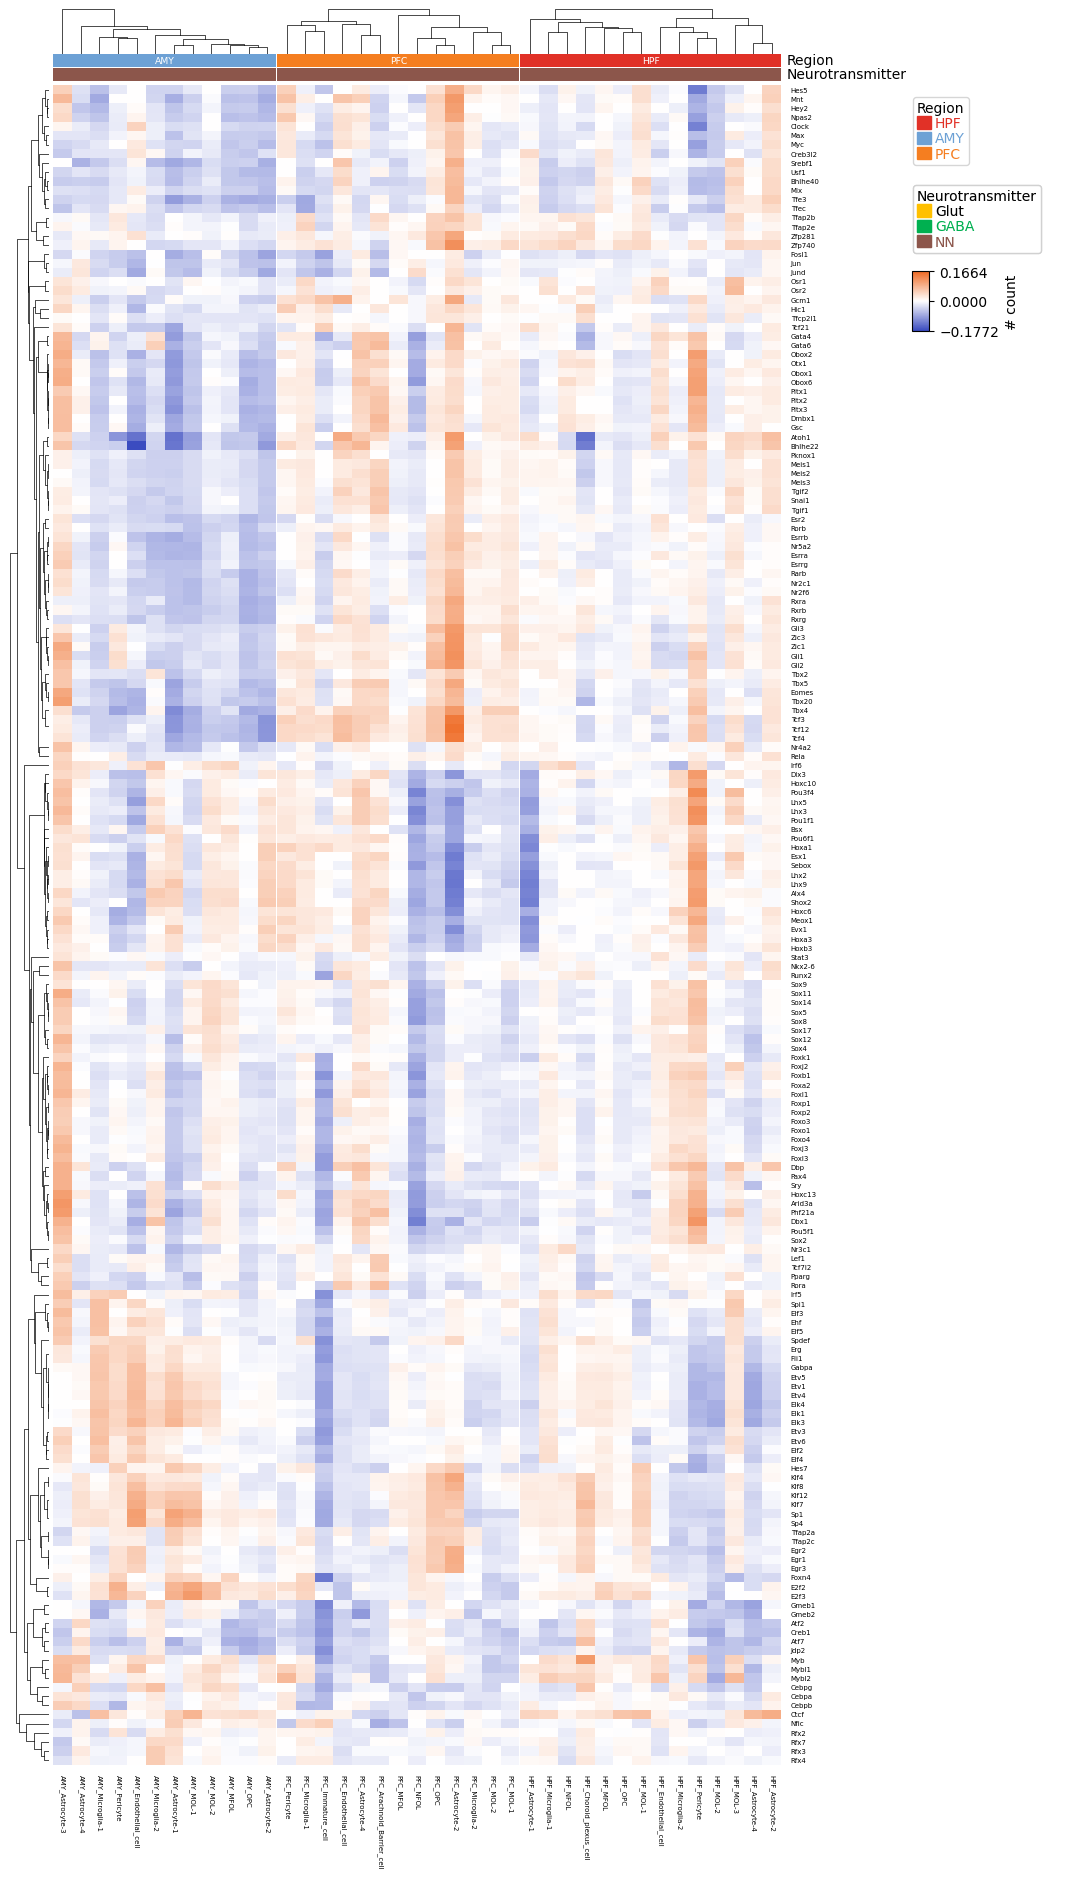

In [15]:

# 修改了 my_module.py 后，重新加载
importlib.reload(utils)

cm = draw_tf_heatmap(results[results.Neurotransmitter!='NN'],value_col="log2FC",figure_size=(15,15)
                     , clipping=0.2,save_fig=f'/home/junyichen/code/scmmd/figures/heatmaptobias_{data_test}.pdf')
cmNN = draw_tf_heatmap(results[results.Neurotransmitter=='NN'],value_col="log2FC", clipping=100,save_fig=f'/home/junyichen/code/scmmd/figures/heatmaptobias_NN_{data_test}.pdf')
# cmavg = draw_tf_heatmap(avg_results[avg_results.Neurotransmitter!='NN'],value_col="log2FC", clipping=0.2,figure_size=(10,25),save_fig='/home/junyichen/code/scmmd/figures/heatmaptobias_N_avg.pdf')
# cmavgNN = draw_tf_heatmap(avg_results[avg_results.Neurotransmitter=='NN'],value_col="log2FC", clipping=0.2,figure_size=(10,25),save_fig='/home/junyichen/code/scmmd/figures/heatmaptobias_NN_avg.pdf')
row_names = list(cm.row_order)[0]
col_names = list(cm.col_order)
mat=cm.data2d.loc[row_names]
mat.to_csv(f'/data2st1/junyi/output/atac1112/tobias/BIND_mat_{data_test}.csv')
# matavg = cmavg.data2d.loc[list(cmavg.row_order)[0]]
# matavg.to_csv('/data2st1/junyi/output/atac1112/tobias/BIND_matavg.csv')
# denrow = cm.dendrogram_row
# cm.dendrogram_row.dendrogram.keys()
# n = len(cm.dendrogram_row.dendrogram["leaves"])
# k = 10
# labels = np.repeat(np.arange(k), n//k + 1)[:n]

In [21]:
full_selected = full_results[full_results.FDR < 0.05]
full_selected['absLog2FC'] = full_selected['log2FC'].abs()
full_selected.sort_values(by=['absLog2FC','total_tfbs'], ascending=[False, False], inplace=True)
full_selected.drop_duplicates(subset=['TF','Region Subclass','status'], inplace=True)

/tmp/ipykernel_1129484/2487230757.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  full_selected['absLog2FC'] = full_selected['log2FC'].abs()
/tmp/ipykernel_1129484/2487230757.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  full_selected.sort_values(by=['absLog2FC','total_tfbs'], ascending=[False, False], inplace=True)
/tmp/ipykernel_1129484/2487230757.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#r

In [22]:
full_selected

,output_prefix,name,motif_id,cluster,total_tfbs,MC_mean_score,MC_bound,MW_mean_score,MW_bound,MC_MW_change,...,Sex,Gene,Neurotransmitter,Region Subclass,FDR,Subclass,Region,status,celltype.L2,absLog2FC
213,metacluster_137.2cisbp__M01001_None,metacluster_137.2#cisbp__M01001,None,C_metacluster_137.2#cisbp__M01805,42058,0.14791,8874,0.16927,10695,-0.41308,...,M,Jund,Glut,PFC_PFC_L4-5_IT_Glut,5.641080e-193,PFC_L4-5_IT_Glut,PFC,Down,PFC_L4-5_IT_Glut,0.41308
281,metacluster_14.17cisbp__M02818_None,metacluster_14.17#cisbp__M02818,None,C_metacluster_128.2#cisbp__M01721,15462,0.23574,5001,0.20543,4435,0.41225,...,M,Bhlhe40,Glut,PFC_PFC_L2-3_IT_Glut,3.738450e-171,PFC_L2-3_IT_Glut,PFC,Up,PFC_L2-3_IT_Glut,0.41225
67,metacluster_64.1cisbp__M00181_None,metacluster_64.1#cisbp__M00181,None,C_metacluster_121.1#cisbp__M02401,39829,0.08652,5737,0.07378,4850,0.40211,...,M,Rxra,Glut,PFC_PFC_L2-3_IT_Glut,3.617700e-187,PFC_L2-3_IT_Glut,PFC,Up,PFC_L2-3_IT_Glut,0.40211
7,metacluster_121.1cisbp__M02402_None,metacluster_121.1#cisbp__M02402,None,C_metacluster_121.1#cisbp__M02401,33700,0.09652,5415,0.08287,4641,0.39166,...,M,Rxrb,Glut,PFC_PFC_L2-3_IT_Glut,1.402270e-182,PFC_L2-3_IT_Glut,PFC,Up,PFC_L2-3_IT_Glut,0.39166
5,metacluster_121.1cisbp__M02400_None,metacluster_121.1#cisbp__M02400,None,C_metacluster_121.1#cisbp__M02401,32135,0.09680,5130,0.08338,4400,0.39026,...,M,Rxrg,Glut,PFC_PFC_L2-3_IT_Glut,6.018280e-183,PFC_L2-3_IT_Glut,PFC,Up,PFC_L2-3_IT_Glut,0.39026
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
159,metacluster_118.1cisbp__M00439_None,metacluster_118.1#cisbp__M00439,None,C_metacluster_118.1#cisbp__M00380,2425,2.12368,112,3.74010,220,0.00024,...,M,Shox2,NN,HPF_MOL-3,3.564320e-02,MOL-3,HPF,Up,MOL-3,0.00024
224,metacluster_67.2cisbp__M00153_None,metacluster_67.2#cisbp__M00153,None,C_metacluster_67.2#cisbp__M00154,1316,5.15344,175,7.84705,289,-0.00012,...,M,E2f3,NN,HPF_MOL-3,2.893230e-02,MOL-3,HPF,Down,MOL-3,0.00012
326,metacluster_142.2cisbp__M08042_None,metacluster_142.2#cisbp__M08042,None,C_metacluster_142.2#cisbp__M08031,37314,0.18162,21632,0.18229,22521,0.00011,...,M,Sox2,NN,AMY_Astrocyte-2,1.942390e-02,Astrocyte-2,AMY,Up,Astrocyte-2,0.00011
143,metacluster_188.5cisbp__M00163_None,metacluster_188.5#cisbp__M00163,None,C_metacluster_188.5#cisbp__M00163,13760,0.44908,1573,0.43975,1585,-0.00008,...,M,Foxk1,Glut,HPF_HPF_Subiculum_SUB_Glut,1.663650e-02,HPF_Subiculum_SUB_Glut,HPF,Down,HPF_Subiculum_SUB_Glut,0.00008


# Region level analysis

In [23]:
df_regions = pd.DataFrame()
valid_files = []
unvalid_files = []
for idx, row in full_selected.iterrows():
    prefix = row['output_prefix']
    region = row['Region'].replace('HPF','HIP')
    subclass = row['Subclass']
    #upbed = f'/data2st2/junyi/output/atac1112/tobiasbam/{region}/{region}_{subclass}_MC_footprints.bw/{prefix}/beds/{prefix}_MC_bound.bed'
    #downbed = f'/data2st2/junyi/output/atac1112/tobiasbam/{region}/{region}_{subclass}_MC_footprints.bw/{prefix}/beds/{prefix}_MW_bound.bed'
    #upbed = f'/data2st2/junyi/output/atac1112/tobiasbam/{region}cisbp_BIND/{region}_{subclass}_MC_footprints.bw/{prefix}/{prefix}_overview.txt'
    upbed = f'/data2st2/junyi/output/atac1112/tobiasbam/{region}cisbp_BIND/{region}_{subclass}_MC_footprints.bw/{prefix}/{prefix}_overview.txt'

    # df_t = pd.read_csv(upbed, sep='\t')
    # df_t['TF'] = row['TF']
    # df_t['Region Subclass'] = row['Region Subclass']
    # df_regions = pd.concat([df_regions, df_t], axis=0)
    if os.path.exists(upbed):
        valid_files.append(upbed)
    else:
        unvalid_files.append(upbed)
    # if os.path.exists(downbed):
    #     valid_files.append(downbed)
    # else:
    #     unvalid_files.append(downbed)

In [24]:
df = dd.read_csv(valid_files, sep='\t', header=0,include_path_column="source_file")
#df.columns = ['chr','start','end','name','score','strand','peak_chr','peak_start','peak_end','bound','source_file']

In [25]:
df_filtered = df[(df['MC_bound']>0) | (df['MW_bound']>0)]
df_filtered['absLog2FC']  = df_filtered['MC_MW_log2fc'].abs()
df_filtered['Region Subclass'] = df_filtered['source_file'].str.split('/').str[7].str[:-17]
df_filtered['Region Subclass'] = df_filtered['Region Subclass'].str.replace('HIP','HPF')
df_filtered['Region Subclass'] = df_filtered['Region Subclass'].str.replace('HPF_HPF','HPF')
df_filtered['Region Subclass'] = df_filtered['Region Subclass'].str.replace('AMY_AMY','AMY')
df_filtered['Region Subclass'] = df_filtered['Region Subclass'].str.replace('PFC_PFC','PFC')
df_filtered['names'] = df_filtered['peak_chr'].astype(str)+':'+df_filtered['peak_start'].astype(str)+'-'+df_filtered['peak_end'].astype(str)
df_filtered['Direction'] = df_filtered['MC_MW_log2fc'].apply(lambda x: 'Up' if x > 0 else 'Down')

/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/dask/dataframe/core.py:4158: UserWarning: 
You did not provide metadata, so Dask is running your function on a small dataset to guess output types. It is possible that Dask will guess incorrectly.
To provide an explicit output types or to silence this message, please provide the `meta=` keyword, as described in the map or apply function that you are using.
  Before: .apply(func)
  After:  .apply(func, meta=('MC_MW_log2fc', 'object'))

  warnings.warn(meta_warning(meta))


In [26]:
df_regions= df_filtered.compute()

In [48]:
df_regions.head()

,TFBS_chr,TFBS_start,TFBS_end,TFBS_name,TFBS_score,TFBS_strand,peak_chr,peak_start,peak_end,MC_score,MW_score,MC_bound,MW_bound,MC_MW_log2fc,source_file,absLog2FC,Region Subclass,names,Direction
5,chr1,3309945,3309954,metacluster_137.2cisbp__M01001_None,9.25971,-,chr1,3309937,3310438,0.11586,0.21381,0,1,-0.76929,/data2st2/junyi/output/atac1112/tobiasbam/PFCc...,0.76929,PFC_L4-5_IT_Glut,chr1:3309937-3310438,Down
16,chr1,3457981,3457990,metacluster_137.2cisbp__M01001_None,9.27677,-,chr1,3457706,3458207,0.43410,0.72141,1,1,-0.70336,/data2st2/junyi/output/atac1112/tobiasbam/PFCc...,0.70336,PFC_L4-5_IT_Glut,chr1:3457706-3458207,Down
30,chr1,5070452,5070461,metacluster_137.2cisbp__M01001_None,8.38934,-,chr1,5070169,5070670,0.58746,0.66948,1,1,-0.18182,/data2st2/junyi/output/atac1112/tobiasbam/PFCc...,0.18182,PFC_L4-5_IT_Glut,chr1:5070169-5070670,Down
33,chr1,5208333,5208342,metacluster_137.2cisbp__M01001_None,8.59528,+,chr1,5208069,5208570,0.21343,0.25563,1,1,-0.23676,/data2st2/junyi/output/atac1112/tobiasbam/PFCc...,0.23676,PFC_L4-5_IT_Glut,chr1:5208069-5208570,Down
38,chr1,6054357,6054366,metacluster_137.2cisbp__M01001_None,8.38934,-,chr1,6054101,6054602,0.09268,0.17249,0,1,-0.75600,/data2st2/junyi/output/atac1112/tobiasbam/PFCc...,0.75600,PFC_L4-5_IT_Glut,chr1:6054101-6054602,Down


In [49]:
dict_tfbs2tf = dict(zip(df_direct_annot['TFBS_name'], df_direct_annot['TF']))

In [50]:
df_regions['TF'] = df_regions['TFBS_name'].str.replace("None_2","None").map(dict_tfbs2tf)

In [ ]:
df_regions_f = df_regions[df_regions['absLog2FC'] >= 0.1]
# df_regions_f['TF'] = df_regions_f['TFBS_name'].str.replace("None_2","None").map(dict_tfbs2tf)

/tmp/ipykernel_1129484/2661574113.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_regions_f['TF'] = df_regions_f['TFBS_name'].str.replace("None_2","None").map(dict_tfbs2tf)


In [32]:
df_annoated = pd.read_csv('/data2st1/junyi/output/atac1112/cCRE/cCRE_annotated_deg250k.csv')

In [ ]:
#df_DAR = pd.read_csv('/data2st1/junyi/output/atac1112/dar/celltype.L2/MASTNG_dar_annotated.csv')

In [ ]:
# df_Group = df_regions_f.groupby(['names', 'Region Subclass','Direction'], as_index=False).agg(
#     combined_TF=('TF', lambda x: '/'.join(x.astype(str))),
#     combined_TFBS=('TFBS_name', lambda x: '/'.join(x.astype(str)))
# )


In [42]:
df_merged_region = pd.merge(df_regions_f,df_annoated,how='inner',on='names')

In [55]:
df_deg = pd.read_csv("/data2st1/junyi/output/atac1112/dar/celltype.L2/mast_ngsa_noco_degs_fdr_log2fc0_filtered.csv")
df_deg['Region Subclass'] = df_deg['Region subclass'].str.replace(" ",'_')
df_deg['Region Subclass'] = df_deg['Region Subclass'].str.replace("/",'-')
df_deg = df_deg[df_deg.Sex=='M']
df_deg = df_deg[df_deg.Region.isin(['HPF','PFC','AMY'])]

In [56]:
df_deg.head()

,Gene,pval,log2FC,ci.hi,ci.lo,FDR,Bonferroni,Subclass,Region,Sex,Method,Ensemble,Gene_name,Direction,Neurotransmitter,Region subclass,Region Subclass
175654,1810062O18Rik,0.005808,0.070354,0.120168,0.020540,0.040524,1.0,Astrocyte-2,PFC,M,MAST,ENSMUSG00000084925,"""1810062O18Rik""",Up,NN,PFC Astrocyte-2,PFC_Astrocyte-2
175655,2610035D17Rik,0.000749,0.088500,0.139018,0.037981,0.009548,1.0,Astrocyte-2,PFC,M,MAST,ENSMUSG00000087259,"""2610035D17Rik""",Up,NN,PFC Astrocyte-2,PFC_Astrocyte-2
175656,4732471J01Rik,0.000876,0.053831,0.097587,0.010075,0.010621,1.0,Astrocyte-2,PFC,M,MAST,ENSMUSG00000053714,"""4732471J01Rik""",Up,NN,PFC Astrocyte-2,PFC_Astrocyte-2
175657,4833420G17Rik,0.004984,0.040075,0.087102,-0.006953,0.036435,1.0,Astrocyte-2,PFC,M,MAST,ENSMUSG00000062822,"""4833420G17Rik""",Up,NN,PFC Astrocyte-2,PFC_Astrocyte-2
175658,4930402H24Rik,0.000780,0.105143,0.164551,0.045736,0.009823,1.0,Astrocyte-2,PFC,M,MAST,ENSMUSG00000027309,"""4930402H24Rik""",Up,NN,PFC Astrocyte-2,PFC_Astrocyte-2


In [71]:
df_merged_region.head()

,TFBS_chr,TFBS_start,TFBS_end,TFBS_name,TFBS_score,TFBS_strand,peak_chr,peak_start,peak_end,MC_score,...,gend,strand,distance,primary_region,secondary_region,encodeCCRE,Sex,Ensemble,Gene,absdistance
0,chr1,3309945,3309954,metacluster_137.2cisbp__M01001_None,9.25971,-,chr1,3309937,3310438,0.11586,...,3671498,-,0,intron,repeat,NaN,M,ENSMUSG00000051951.5,chr1:3309937-3310438,0
1,chr1,3309944,3309955,metacluster_137.2transfac_public__M00174_None,8.14157,-,chr1,3309937,3310438,0.11586,...,3671498,-,0,intron,repeat,NaN,M,ENSMUSG00000051951.5,chr1:3309937-3310438,0
2,chr1,3309945,3309956,metacluster_137.2cisbp__M01805_None,8.69334,-,chr1,3309937,3310438,0.11586,...,3671498,-,0,intron,repeat,NaN,M,ENSMUSG00000051951.5,chr1:3309937-3310438,0
3,chr1,3309945,3309954,metacluster_137.2cisbp__M01001_None,9.34861,-,chr1,3309937,3310438,0.36816,...,3671498,-,0,intron,repeat,NaN,M,ENSMUSG00000051951.5,chr1:3309937-3310438,0
4,chr1,3309944,3309955,metacluster_137.2transfac_public__M00174_None,8.29504,-,chr1,3309937,3310438,0.36816,...,3671498,-,0,intron,repeat,NaN,M,ENSMUSG00000051951.5,chr1:3309937-3310438,0


In [77]:
df_test_TF_gene

,TFBS_chr,TFBS_start,TFBS_end,TFBS_name,TFBS_score,TFBS_strand,peak_chr,peak_start,peak_end,MC_score,...,Bonferroni,Subclass,Region,Sex_deg,Method,Ensemble_deg,Gene_name,Direction_deg,Neurotransmitter,Region subclass
0,chr1,5070452,5070461,metacluster_137.2cisbp__M01001_None,8.38934,-,chr1,5070169,5070670,0.58746,...,1.000000e+00,PFC L4/5 IT Glut,PFC,M,MAST,ENSMUSG00000033793,"""Atp6v1h""",Up,Glut,PFC L4/5 IT Glut
1,chr1,5070451,5070462,metacluster_137.2transfac_public__M00174_None,7.94727,-,chr1,5070169,5070670,0.58746,...,1.000000e+00,PFC L4/5 IT Glut,PFC,M,MAST,ENSMUSG00000033793,"""Atp6v1h""",Up,Glut,PFC L4/5 IT Glut
2,chr1,5070414,5070429,metacluster_159.3cisbp__M08022_None,7.45058,+,chr1,5070169,5070670,0.58746,...,1.000000e+00,PFC L4/5 IT Glut,PFC,M,MAST,ENSMUSG00000033793,"""Atp6v1h""",Up,Glut,PFC L4/5 IT Glut
3,chr1,5083086,5083095,metacluster_128.2cisbp__M00119_None,8.68467,-,chr1,5082867,5083368,1.42835,...,1.000000e+00,PFC L4/5 IT Glut,PFC,M,MAST,ENSMUSG00000033793,"""Atp6v1h""",Up,Glut,PFC L4/5 IT Glut
4,chr1,5083086,5083095,metacluster_128.2cisbp__M00119_None,8.68467,-,chr1,5082867,5083368,1.42835,...,1.000000e+00,PFC L4/5 IT Glut,PFC,M,MAST,ENSMUSG00000033793,"""Atp6v1h""",Up,Glut,PFC L4/5 IT Glut
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2050964,chr6,96113025,96113034,metacluster_118.1cisbp__M00504_None,6.25281,-,chr6,96112899,96113400,0.13767,...,1.761332e-28,AMY Ccdc3_Acvr1c Glut,AMY,M,MAST,ENSMUSG00000059187,"""Tafa1""",Down,Glut,AMY Ccdc3_Acvr1c Glut
2050965,chr13,15807014,15807029,metacluster_167.5cisbp__M08027_None,7.59318,+,chr13,15806801,15807302,0.28794,...,1.000000e+00,HPF CA3 Glut,HPF,M,MAST,ENSMUSG00000113338,"""A530046M15Rik""",Up,Glut,HPF CA3 Glut
2050966,chr14,69838516,69838528,metacluster_127.2cisbp__M01984_None,7.93515,-,chr14,69838486,69838987,0.15473,...,1.000000e+00,AMY Rorb_Smoc1 Glut,AMY,M,MAST,ENSMUSG00000022085,"""Pebp4""",Down,Glut,AMY Rorb_Smoc1 Glut
2050967,chr14,122913520,122913529,metacluster_4.2cisbp__M00210_None,6.26341,-,chr14,122913503,122914004,0.16174,...,1.000000e+00,AMY Ccdc3_Acvr1c Glut,AMY,M,MAST,ENSMUSG00000041625,"""Ggact""",Down,Glut,AMY Ccdc3_Acvr1c Glut


In [ ]:
# for TF in df_test_TF_gene['TF'].unique():
#     df_tf = df_test_TF_gene[df_test_TF_gene['TF'] == TF]
#     concordant = sum(df_tf['Direction_deg'] == df_tf['Direction_tobias'])
#     total = df_tf.shape[0]
#     concordance_rate = concordant / total
#     print(f'TF: {TF}, Concordance Rate: {concordance_rate:.2f} ({concordant}/{total})')

In [82]:
def archr_distance_weight(d):
    d = abs(d)
    return np.exp(-d/5000) + np.exp(-1)

def copute_weighted_score(df_input):
    df_input['distance_weight'] = df_input['distance'].apply(archr_distance_weight)
    df_input["MC_Weighted"] = df_input["MC_score"] * df_input["distance_weight"]
    df_input["MW_Weighted"] = df_input["MW_score"] * df_input["distance_weight"]
    df_trimed = df_input[(df_input.distance <= 100000) & (df_input.distance >= -100000)]
    df_trimed_grouped =  df_trimed.groupby(['gene_name','Region Subclass']).sum().reset_index()
    df_trimed_grouped['log2FC'] = np.log2((df_trimed_grouped['MC_Weighted'] + 1e-10) / (df_trimed_grouped['MW_Weighted'] + 1e-10))
    df_trimed_grouped['Region subclass'] = df_trimed_grouped['Region Subclass']
    #Direction	Region	Neurotransmitter	Sex	Gene	Subclass
    df_trimed_grouped['Direction'] = df_trimed_grouped['log2FC'].apply(lambda x: 'Up' if x > 0 else 'Down')
    df_trimed_grouped['Sex'] = 'M'
    df_trimed_grouped['Gene'] = df_trimed_grouped['gene_name']
    df_trimed_grouped['Neurotransmitter'] = df_trimed_grouped['Region Subclass'].apply(lambda x: 'Glut' if 'Glut' in x else ('GABA' if 'GABA' in x else 'NN'))
    df_trimed_grouped['Subclass'] = df_trimed_grouped['Region Subclass']
    df_trimed_grouped.loc[df_trimed_grouped.Neurotransmitter=='NN','Subclass'] = df_trimed_grouped.loc[df_trimed_grouped.Neurotransmitter=='NN','Subclass'].str[4:]
    df_trimed_grouped['Region'] = df_trimed_grouped['Region Subclass'].str[:3].str.replace('HIP','HPF')
    return df_trimed_grouped

array(['Jund', 'Jun', 'Fosl1', 'Pknox1', 'Meis3', 'Meis2', 'Tgif2',
       'Meis1', 'Snai1', 'Tgif1', 'Tcf21', 'Phf21a', 'Spi1', 'Elf5',
       'Elf3', 'Foxj2', 'Stat3', 'Foxb1', 'Ehf', 'Zfp740', 'Zfp281',
       'Egr3', 'Egr1', 'Rela', 'Foxl1', 'Pou1f1', 'Gata6', 'Foxa2',
       'Nkx2-6', 'Tfcp2l1', 'Ctcf', 'Myb', 'Mybl1', 'Hic1', 'Mybl2',
       'Sox14', 'Sox5', 'Sox8', 'Nr3c1', 'Sox12', 'Sox4', 'Sox17',
       'Bhlhe22', 'Atoh1', 'Arid3a', 'Dbx1', 'Pou5f1', 'Hoxc10', 'Rora',
       'Cebpa', 'Foxl3', 'Hoxc13', 'Esr2', 'Tbx2', 'Nfic', 'Sox2', 'Dbp',
       'Cebpb', 'Jdp2', 'Lhx5', 'Foxo4', 'Foxk1', 'Sry', 'Eomes', 'Foxo1',
       'Foxo3', 'Foxj3', 'Foxp2', 'Tbx20', 'Foxp1', 'Osr1', 'Osr2',
       'Gli3', 'Tbx5', 'Rxra', 'Rxrb', 'Rxrg', 'Nr2c1', 'Pitx2', 'Obox2',
       'Rfx2', 'Pitx3', 'Dmbx1', 'Otx1', 'Rfx7', 'Pitx1', 'Pax4', 'Gsc',
       'Sp4', 'Klf4', 'Klf8', 'Sp1', 'Klf12', 'Klf7', 'Srebf1', 'Tfe3',
       'Pparg', 'Etv3', 'Esrrb', 'Elf4', 'Tfec', 'Erg', 'Fli1', 'Gabpa',
       '

In [185]:
from matplotlib_venn import venn2
def draw_venndiagram(df1, df2,savepath=None,showplot=False,set_labels=("Tobias", "deg")):
    # df1 = df[df['exp'] == exp1]
    # df2 = df[df['exp'] == exp2]
    gene_list1 = df1['gene_name']+"_"+df1['Direction']+"_"+df1['Region Subclass']
    gene_list2 = df2['Gene']+"_"+df2['Direction']+"_"+df2['Region Subclass']
    set1 = set(gene_list1)
    set2 = set(gene_list2)
    venn2([set1, set2], set_labels = set_labels)
    if showplot:
        plt.show()
    if savepath:
        plt.savefig(savepath,dpi=300)
    plt.close()

    return set1, set2

In [145]:
IoUs= []
TFs = []
pctDEG = []
for TF in df_merged_region.TF.unique():
    df_TF_jun = df_merged_region[df_merged_region.TF==TF]
    df_TF_jun_wg = copute_weighted_score(df_TF_jun)
    set1,set2 = draw_venndiagram(df_TF_jun, df_deg,savepath=f'/data2st1/junyi/output/atac1112/tobias/testdeg/venn_{TF}_tobias_deg.pdf')
    intersection = set1.intersection(set2)
    union = set1.union(set2)
    iou = len(intersection) / len(union) if len(union) > 0 else 0
    IoUs.append(iou)
    TFs.append(TF)
    pctDEG.append(len(intersection)/len(set2) if len(set2)>0 else 0)

/tmp/ipykernel_1129484/3602613066.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_input['distance_weight'] = df_input['distance'].apply(archr_distance_weight)
/tmp/ipykernel_1129484/3602613066.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_input["MC_Weighted"] = df_input["MC_score"] * df_input["distance_weight"]
/tmp/ipykernel_1129484/3602613066.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value ins

In [143]:
df_results= pd.DataFrame({'TF':TFs, 'IoU':IoUs})

In [144]:
df_results

,TF,IoU
0,Jund,0.060277
1,Jun,0.055206
2,Fosl1,0.057872
3,Pknox1,0.058750
4,Meis3,0.058260
...,...,...
179,Max,0.045962
180,Clock,0.043679
181,E2f2,0.041725
182,Hes5,0.046855


In [ ]:
df_TF_jun_wg.merge(df_deg, how='inner', left_on=['Region Subclass','gene_name','Direction'], right_on=['Region Subclass','Gene','Direction'],suffixes=('_tobias','_deg'))

,gene_name,Region Subclass,TFBS_start,TFBS_end,TFBS_score,peak_start,peak_end,MC_score,MW_score,MC_bound,...,FDR_deg,Bonferroni_deg,Subclass_deg,Region_deg,Sex_deg,Method,Ensemble,Gene_name,Neurotransmitter_deg,Region subclass_deg
0,1110004F10Rik,HPF_Lamp5_GABA,116093218,116093227,7.86644,116093005,116093506,4.12344,3.17984,1,...,0.016318,1.000000,HPF Lamp5 GABA,HPF,M,MAST,ENSMUSG00000030663,"""1110004F10Rik""",GABA,HPF Lamp5 GABA
1,1110059E24Rik,AMY_Ccdc3_Acvr1c_Glut,21652852,21652861,7.97008,21652832,21653333,0.93313,0.63705,1,...,0.026012,1.000000,AMY Ccdc3_Acvr1c Glut,AMY,M,MAST,ENSMUSG00000035171,"""1110059E24Rik""",Glut,AMY Ccdc3_Acvr1c Glut
2,1110065P20Rik,HPF_CA3_Glut,124850739,124850748,7.82109,124850471,124850972,1.47198,1.35147,1,...,0.036476,1.000000,HPF CA3 Glut,HPF,M,MAST,ENSMUSG00000078570,"""1110065P20Rik""",Glut,HPF CA3 Glut
3,1600010M07Rik,AMY_Tcf7l2_Gm20713_Glut,110121929,110121940,7.66592,110121675,110122176,2.59775,3.40833,1,...,0.033529,1.000000,AMY Tcf7l2_Gm20713 Glut,AMY,M,MAST,ENSMUSG00000101585,"""1600010M07Rik""",Glut,AMY Tcf7l2_Gm20713 Glut
4,1810013L24Rik,AMY_Cav1_Frmpd1_Glut,8829703,8829714,7.43919,8829644,8830145,3.98734,5.06208,1,...,0.009663,1.000000,AMY Cav1_Frmpd1 Glut,AMY,M,MAST,ENSMUSG00000022507,"""1810013L24Rik""",Glut,AMY Cav1_Frmpd1 Glut
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2036,Zmym2,AMY_Piezo2_Cpa6_Glut,56885278,56885287,8.27399,56885169,56885670,0.08378,0.13703,0,...,0.000002,0.003136,AMY Piezo2_Cpa6 Glut,AMY,M,MAST,ENSMUSG00000021945,"""Zmym2""",Glut,AMY Piezo2_Cpa6 Glut
2037,Znfx1,PFC_L4-5_IT_Glut,167060954,167060965,9.47071,167060724,167061225,0.48612,0.55861,1,...,0.015354,1.000000,PFC L4/5 IT Glut,PFC,M,MAST,ENSMUSG00000039501,"""Znfx1""",Glut,PFC L4/5 IT Glut
2038,Zscan22,AMY_Ccdc3_Acvr1c_Glut,12897825,12897834,7.86317,12897522,12898023,2.08097,2.38805,1,...,0.031709,1.000000,AMY Ccdc3_Acvr1c Glut,AMY,M,MAST,ENSMUSG00000054715,"""Zscan22""",Glut,AMY Ccdc3_Acvr1c Glut
2039,Zswim7,PFC_L2-3_IT_Glut,62281431,62281440,8.67881,62281165,62281666,2.28274,2.05630,1,...,0.000089,0.134981,PFC L2/3 IT Glut,PFC,M,MAST,ENSMUSG00000014243,"""Zswim7""",Glut,PFC L2/3 IT Glut


In [116]:
df_DAR = pd.read_csv('/data2st1/junyi/output/atac1112/dar/celltype.L2/MASTNG_dar_annotated_with_TFs.csv')
df_DAR['distance_weight'] = df_DAR['distance'].apply(archr_distance_weight)
df_DAR["log2FC_Weighted"] = df_DAR["log2FC"] * df_DAR["distance_weight"]


In [192]:
df_merged_region['Region'] = df_merged_region['Region Subclass'].str[:3].str.replace('HIP','HPF')

In [197]:
df_merged_region.head()

,TFBS_chr,TFBS_start,TFBS_end,TFBS_name,TFBS_score,TFBS_strand,peak_chr,peak_start,peak_end,MC_score,...,strand,distance,primary_region,secondary_region,encodeCCRE,Sex,Ensemble,Gene,absdistance,Region
0,chr1,3309945,3309954,metacluster_137.2cisbp__M01001_None,9.25971,-,chr1,3309937,3310438,0.11586,...,-,0,intron,repeat,NaN,M,ENSMUSG00000051951.5,chr1:3309937-3310438,0,PFC
1,chr1,3309944,3309955,metacluster_137.2transfac_public__M00174_None,8.14157,-,chr1,3309937,3310438,0.11586,...,-,0,intron,repeat,NaN,M,ENSMUSG00000051951.5,chr1:3309937-3310438,0,PFC
2,chr1,3309945,3309956,metacluster_137.2cisbp__M01805_None,8.69334,-,chr1,3309937,3310438,0.11586,...,-,0,intron,repeat,NaN,M,ENSMUSG00000051951.5,chr1:3309937-3310438,0,PFC
3,chr1,3309945,3309954,metacluster_137.2cisbp__M01001_None,9.34861,-,chr1,3309937,3310438,0.36816,...,-,0,intron,repeat,NaN,M,ENSMUSG00000051951.5,chr1:3309937-3310438,0,HPF
4,chr1,3309944,3309955,metacluster_137.2transfac_public__M00174_None,8.29504,-,chr1,3309937,3310438,0.36816,...,-,0,intron,repeat,NaN,M,ENSMUSG00000051951.5,chr1:3309937-3310438,0,HPF


In [202]:
df_merged = pd.merge(df_tmp_promoter,df_deg_region, how='inner', left_on=['Region Subclass','gene_name','Direction'], right_on=['Region Subclass','Gene','Direction'],suffixes=('_tobias','_dar'))

In [ ]:
df_merged.sort_values(by=['absLog2FC_tobias','total_tfbs'], ascending=[False, False], inplace=True)

,TFBS_chr,TFBS_start,TFBS_end,TFBS_name,TFBS_score,TFBS_strand,peak_chr,peak_start,peak_end,MC_score,...,FDR,Bonferroni,Subclass,Region_dar,Sex_dar,Method,Ensemble_dar,Gene_name,Neurotransmitter,Region subclass
0,chr1,5070372,5070393,metacluster_175.2cisbp__M08029_None,7.25703,-,chr1,5070169,5070670,0.61371,...,4.081071e-03,1.000000e+00,AMY Zfhx4_Pde7b GABA,AMY,M,MAST,ENSMUSG00000033793,"""Atp6v1h""",GABA,AMY Zfhx4_Pde7b GABA
1,chr1,5070367,5070377,metacluster_113.4cisbp__M00179_None,7.41923,+,chr1,5070169,5070670,0.60486,...,4.081071e-03,1.000000e+00,AMY Zfhx4_Pde7b GABA,AMY,M,MAST,ENSMUSG00000033793,"""Atp6v1h""",GABA,AMY Zfhx4_Pde7b GABA
2,chr1,5070414,5070429,metacluster_159.3cisbp__M08022_None,7.47601,+,chr1,5070169,5070670,0.61371,...,4.081071e-03,1.000000e+00,AMY Zfhx4_Pde7b GABA,AMY,M,MAST,ENSMUSG00000033793,"""Atp6v1h""",GABA,AMY Zfhx4_Pde7b GABA
3,chr1,5070367,5070376,metacluster_113.4cisbp__M00180_None,7.55290,+,chr1,5070169,5070670,0.57121,...,4.081071e-03,1.000000e+00,AMY Zfhx4_Pde7b GABA,AMY,M,MAST,ENSMUSG00000033793,"""Atp6v1h""",GABA,AMY Zfhx4_Pde7b GABA
4,chr1,5070367,5070376,metacluster_113.4cisbp__M00807_None,7.29179,+,chr1,5070169,5070670,0.57121,...,4.081071e-03,1.000000e+00,AMY Zfhx4_Pde7b GABA,AMY,M,MAST,ENSMUSG00000033793,"""Atp6v1h""",GABA,AMY Zfhx4_Pde7b GABA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
630111,chr6,96113025,96113034,metacluster_118.1cisbp__M00395_None,6.11133,-,chr6,96112899,96113400,0.13767,...,4.295930e-30,1.761332e-28,AMY Ccdc3_Acvr1c Glut,AMY,M,MAST,ENSMUSG00000059187,"""Tafa1""",Glut,AMY Ccdc3_Acvr1c Glut
630112,chr6,96113252,96113262,metacluster_189.1cisbp__M00198_None,8.00310,+,chr6,96112899,96113400,0.08366,...,4.295930e-30,1.761332e-28,AMY Ccdc3_Acvr1c Glut,AMY,M,MAST,ENSMUSG00000059187,"""Tafa1""",Glut,AMY Ccdc3_Acvr1c Glut
630113,chr6,96113252,96113262,metacluster_189.1cisbp__M00200_None,8.08851,+,chr6,96112899,96113400,0.08366,...,4.295930e-30,1.761332e-28,AMY Ccdc3_Acvr1c Glut,AMY,M,MAST,ENSMUSG00000059187,"""Tafa1""",Glut,AMY Ccdc3_Acvr1c Glut
630114,chr6,96113025,96113034,metacluster_118.1cisbp__M00504_None,6.25281,-,chr6,96112899,96113400,0.13767,...,4.295930e-30,1.761332e-28,AMY Ccdc3_Acvr1c Glut,AMY,M,MAST,ENSMUSG00000059187,"""Tafa1""",Glut,AMY Ccdc3_Acvr1c Glut


In [199]:
df_merged

,TFBS_chr,TFBS_start,TFBS_end,TFBS_name,TFBS_score,TFBS_strand,peak_chr,peak_start,peak_end,MC_score,...,log2FC,Neurotransmitter,Gene_name,FDR,Region Subclass Direction,TFs,motifs,method,distance_weight,log2FC_Weighted
0,chr1,3310135,3310143,metacluster_68.2cisbp__M00399_None,6.40573,+,chr1,3309937,3310438,0.20840,...,-0.025041,Glut,chr1:3433764-3434265,2.887007e-09,PFC_L2-3_IT_Glut_Down,[Rarg],hdpi__RARG,MASTNG,1.367879,-0.034253
1,chr1,3310135,3310143,metacluster_68.2cisbp__M00399_None,6.40573,+,chr1,3309937,3310438,0.20840,...,-0.000076,Glut,chr1:3672006-3672507,3.529636e-02,PFC_L2-3_IT_Glut_Down,"[2610021A01Rik, E2f1, E2f2, Gm28168, Gm28360, ...",transfac_pro__M04866/hocomoco__ZBT14_HUMAN.H11...,MASTNG,1.271090,-0.000097
2,chr1,3310134,3310143,metacluster_68.2cisbp__M00488_None,7.29796,+,chr1,3309937,3310438,0.20840,...,-0.025041,Glut,chr1:3433764-3434265,2.887007e-09,PFC_L2-3_IT_Glut_Down,[Rarg],hdpi__RARG,MASTNG,1.367879,-0.034253
3,chr1,3310134,3310143,metacluster_68.2cisbp__M00488_None,7.29796,+,chr1,3309937,3310438,0.20840,...,-0.000076,Glut,chr1:3672006-3672507,3.529636e-02,PFC_L2-3_IT_Glut_Down,"[2610021A01Rik, E2f1, E2f2, Gm28168, Gm28360, ...",transfac_pro__M04866/hocomoco__ZBT14_HUMAN.H11...,MASTNG,1.271090,-0.000097
4,chr1,3310134,3310143,metacluster_68.2cisbp__M00437_None,6.91799,+,chr1,3309937,3310438,0.20840,...,-0.025041,Glut,chr1:3433764-3434265,2.887007e-09,PFC_L2-3_IT_Glut_Down,[Rarg],hdpi__RARG,MASTNG,1.367879,-0.034253
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20391760,chr7,27733038,27733048,metacluster_131.7cisbp__M00776_None,7.07956,+,chr7,27732799,27733300,0.15454,...,0.015280,Glut,chr7:27731171-27731672,2.693608e-03,AMY_Ccdc3_Acvr1c_Glut_Up,NaN,NaN,NaN,1.367879,0.020901
20391761,chr7,27733039,27733049,metacluster_131.7cisbp__M00138_None,7.08617,+,chr7,27732799,27733300,0.15454,...,0.015280,Glut,chr7:27731171-27731672,2.693608e-03,AMY_Ccdc3_Acvr1c_Glut_Up,NaN,NaN,NaN,1.367879,0.020901
20391762,chr13,38664369,38664377,metacluster_169.2cisbp__M00165_None,6.80929,+,chr13,38664125,38664626,0.13653,...,0.000604,Glut,chr13:38658299-38658800,1.735635e-02,AMY_Piezo2_Cpa6_Glut_Up,NaN,NaN,NaN,1.367879,0.000826
20391763,chr8,8694350,8694359,metacluster_169.2cisbp__M00799_None,6.23419,+,chr8,8693859,8694360,0.17233,...,0.005271,Glut,chr8:8689790-8690291,1.414312e-02,AMY_Zbtb7c_Vwa5b1_Glut_Up,"[Acaa1a, Acaa1b, Brca1, Chd2, Creb1, E2f1, E2f...",metacluster_55.3/dbtfbs__E2F8_representative_N...,MASTNG,1.367879,0.007210


In [117]:
df_DAR['TFs'] = df_DAR['TFs'].str.split('/')

In [118]:
df_DAR_expanded = df_DAR.explode('TFs').reset_index(drop=True)

In [344]:
from matplotlib import cm
def show_stacked_barplot(df_DAR,column_status="primary_region",direction_col="Direction",title=''):
    df = df_DAR.copy()
    # Aggregate
    up_df = df[df[direction_col] == "Up"].groupby(["Region Subclass", column_status]).size().unstack(fill_value=0)
    down_df = df[df[direction_col] == "Down"].groupby(["Region Subclass", column_status]).size().unstack(fill_value=0)

    # Down values become negative
    down_df = -down_df

    # Unified color palette for primary regions
    categories = up_df.columns
    cmap = cm.get_cmap("tab10", len(categories))  # or "Set3", "tab10", etc.
    colors = {cat: cmap(i) for i, cat in enumerate(categories)}


    plt.figure(figsize=(18,8))

    # ----- Plot Up (positive) -----
    bottom_up = None
    for region in up_df.columns:
        plt.bar(
            up_df.index,
            up_df[region],
            bottom=bottom_up,
            color=colors[region],
            edgecolor="black",
            linewidth=0.3,
            label=region if bottom_up is None else ""
        )
        bottom_up = up_df[region] if bottom_up is None else bottom_up + up_df[region]

    # ----- Plot Down (negative) -----
    bottom_down = None
    for region in down_df.columns:
        plt.bar(
            down_df.index,
            down_df[region],
            bottom=bottom_down,
            color=colors[region],
            edgecolor="black",
            linewidth=0.3
        )
        bottom_down = down_df[region] if bottom_down is None else bottom_down + down_df[region]

    # Formatting
    plt.axhline(0, color='black', linewidth=1)
    plt.xticks(rotation=90)
    plt.ylabel("Count")
    plt.title(title)

    # SINGLE legend (only regions)
    handles = [plt.Rectangle((0,0),1,1,color=colors[r]) for r in up_df.columns]
    plt.legend(handles, up_df.columns, bbox_to_anchor=(1.02,1), loc='upper left', title="Primary Region")

    plt.tight_layout()
    plt.show()


In [ ]:
df_DAR_expanded['absLog2FC'] = df_DAR_expanded['log2FC_Weighted'].abs()
df_DAR_expanded.sort_values(by=['absLog2FC'], ascending=[False], inplace=True)
df_DAR_expanded.drop_duplicates(subset=['TFs','Region Subclass','names','status'],inplace=True)

In [256]:
df_DAR_expanded['TF']= df_DAR_expanded['TFs']

In [338]:
df_DAR_expanded['Gene'] = df_DAR_expanded['gene_name']
df_merged_region['Gene'] = df_merged_region['gene_name']

/tmp/ipykernel_1129484/873173439.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tmp_promoter.sort_values(by=['absLog2FC'], ascending=[False], inplace=True)
/tmp/ipykernel_1129484/873173439.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_deg_merge_promoter['TF_gene'] = 'Promoter'
/tmp/ipykernel_1129484/1576934453.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get

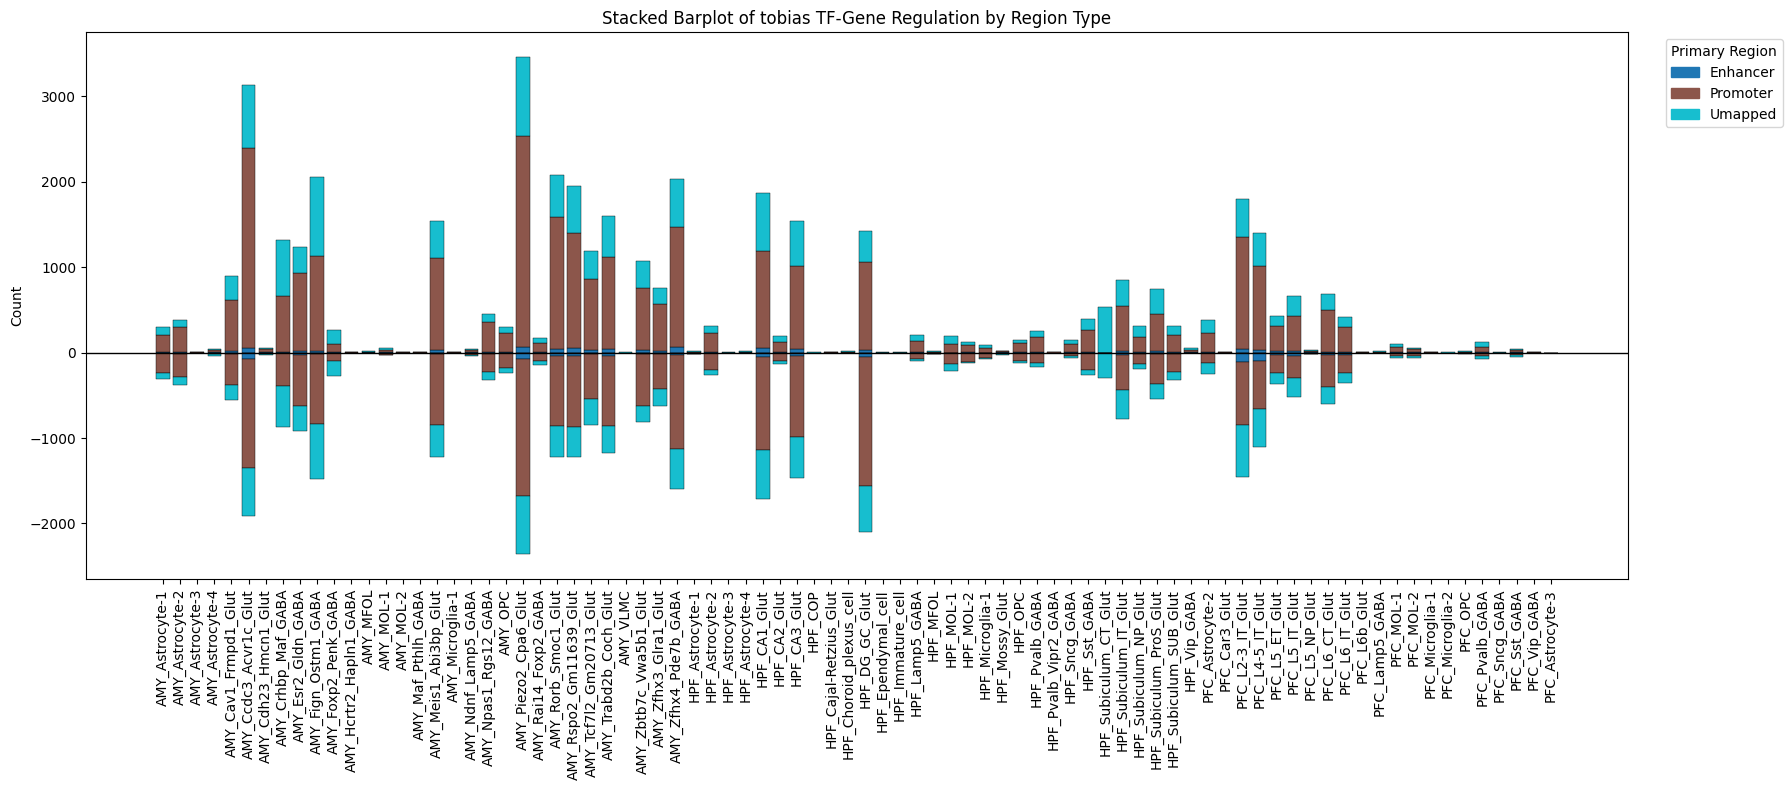

/tmp/ipykernel_1129484/873173439.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tmp_promoter.sort_values(by=['absLog2FC'], ascending=[False], inplace=True)
/tmp/ipykernel_1129484/873173439.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_deg_merge_promoter['TF_gene'] = 'Promoter'
/tmp/ipykernel_1129484/1576934453.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get

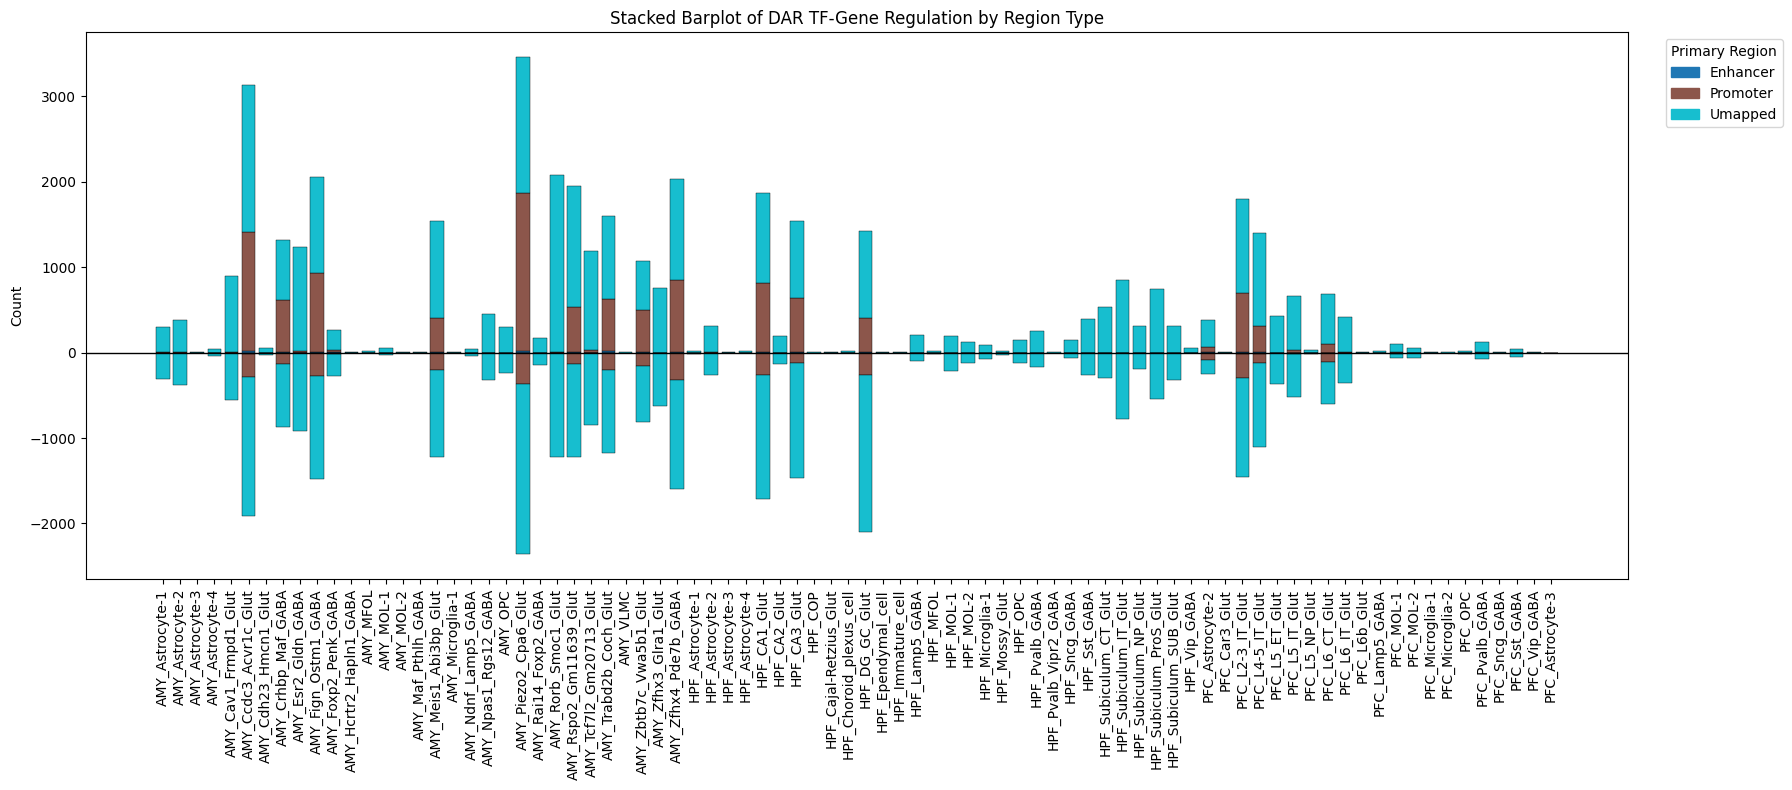

In [345]:
for exp, df_tmp_all in [("tobias", df_merged_region),('DAR',df_DAR_expanded)]:#,("tobias", df_merged_region) #('DAR',df_DAR_expanded)

    df_tmp_promoter = df_tmp_all[df_tmp_all['primary_region']=='promoter']
    df_tmp_promoter.sort_values(by=['absLog2FC'], ascending=[False], inplace=True)
    df_unq = df_tmp_promoter.drop_duplicates(subset=['gene_name','Region Subclass','TF'])
    df_deg_merge = pd.merge(df_unq, df_deg, how='right', left_on=['Region Subclass','Gene','Direction'], right_on=['Region Subclass','Gene','Direction'],
                     suffixes=('_promoter','_deg'),indicator='promoter')
    df_deg_merge_gene = df_deg_merge.drop_duplicates(subset=['Region Subclass','Gene','Direction'])
    df_deg_merge_promoter = df_deg_merge_gene[df_deg_merge_gene['promoter']=='both']
    df_deg_merge_nomap = df_deg_merge_gene[df_deg_merge_gene['promoter']=='right_only']

    df_deg_merge_nomap = df_deg_merge_nomap.dropna(axis=1)
    df_near_proximal = df_tmp_all[(df_tmp_all['primary_region']=='distal')]
    df_deg_merge_proxima = pd.merge(df_near_proximal, df_deg_merge_nomap, how='right', left_on=['Region Subclass','Gene','Direction'], right_on=['Region Subclass','Gene','Direction'],
                        suffixes=('_prx','_degn'),indicator='nearproximal')

    df_deg_merge_proxima = df_deg_merge_proxima.drop_duplicates(subset=['Region Subclass','Gene','Direction'])
    df_deg_merge_proxima['TF_gene'] = df_deg_merge_proxima['nearproximal'].map({'both':'Enhancer','right_only':'Umapped'})
    df_deg_merge_promoter['TF_gene'] = 'Promoter'
    df_promoter_final = df_deg_merge_promoter[['Gene','Region Subclass','Direction','TF_gene']]
    df_enhancer_final = df_deg_merge_proxima[['Gene','Region Subclass','Direction','TF_gene']]
    df_grn_final = pd.concat([df_promoter_final, df_enhancer_final], axis=0)
    show_stacked_barplot(df_grn_final, column_status="TF_gene", title=f'Stacked Barplot of {exp} TF-Gene Regulation by Region Type')


In [349]:
df_tmp_all.shape

(9420206, 40)

In [ ]:
for region in df_deg.Region.unique():
    for exp, df_tmp_all in [("DAR", df_DAR), ("tobias", df_merged_region)]:
        df_deg_region = df_deg[df_deg['Region'] == region]
        df_tmp = df_tmp_all[df_tmp_all['Region'] == region]
        df_tmp_promoter = df_tmp[df_tmp['primary_region']=='promoter']
        draw_venndiagram(df_tmp_promoter, df_deg_region,showplot=False,set_labels=(exp, "deg"),savepath=f'/data2st1/junyi/output/atac1112/tobias/testdeg/venn_{region}_{exp}_promoter_deg.pdf')

        df_proximal = df_tmp[(df_tmp['primary_region']=='distal')&(df_tmp['distance'].abs() <= 50000)]
        draw_venndiagram(df_proximal, df_deg_region,showplot=False,set_labels=(exp, "deg"),savepath=f'/data2st1/junyi/output/atac1112/tobias/testdeg/venn_{region}_{exp}_proximal_deg.pdf')
        
        df_distal = df_tmp[(df_tmp['primary_region']=='distal')&(df_tmp['distance'].abs() > 50000)]
        draw_venndiagram(df_distal, df_deg_region,showplot=False,set_labels=(exp, "deg"),savepath=f'/data2st1/junyi/output/atac1112/tobias/testdeg/venn_{region}_{exp}_distal_deg.pdf')

In [122]:
df_DAR_expanded

,names,Pr(>Chisq),coef,ci.hi,ci.lo,padjust,celltype.L2,region,ctname,fdr,...,Neurotransmitter,Gene_name,FDR,Region Subclass Direction,TFs,motifs,method,distance_weight,log2FC_Weighted,absLog2FC
7916039,chr14:122450957-122451458,0.000007,3.787613e-01,0.588256,0.169266,0.06638,Astrocyte-4,PFC,PFC_Astrocyte.4,0.03319,...,NN,chr14:122450957-122451458,0.03319,PFC_Astrocyte-4_Up,Gm49345,transfac_pro__M05720/transfac_public__M00433/s...,MASTNG,1.367879,5.180998e-01,5.180998e-01
7916081,chr14:122450957-122451458,0.000007,3.787613e-01,0.588256,0.169266,0.06638,Astrocyte-4,PFC,PFC_Astrocyte.4,0.03319,...,NN,chr14:122450957-122451458,0.03319,PFC_Astrocyte-4_Up,Sp3,transfac_pro__M05720/transfac_public__M00433/s...,MASTNG,1.367879,5.180998e-01,5.180998e-01
7916102,chr14:122450957-122451458,0.000007,3.787613e-01,0.588256,0.169266,0.06638,Astrocyte-4,PFC,PFC_Astrocyte.4,0.03319,...,NN,chr14:122450957-122451458,0.03319,PFC_Astrocyte-4_Up,Zfp54,transfac_pro__M05720/transfac_public__M00433/s...,MASTNG,1.367879,5.180998e-01,5.180998e-01
7916052,chr14:122450957-122451458,0.000007,3.787613e-01,0.588256,0.169266,0.06638,Astrocyte-4,PFC,PFC_Astrocyte.4,0.03319,...,NN,chr14:122450957-122451458,0.03319,PFC_Astrocyte-4_Up,Klf10,transfac_pro__M05720/transfac_public__M00433/s...,MASTNG,1.367879,5.180998e-01,5.180998e-01
7916097,chr14:122450957-122451458,0.000007,3.787613e-01,0.588256,0.169266,0.06638,Astrocyte-4,PFC,PFC_Astrocyte.4,0.03319,...,NN,chr14:122450957-122451458,0.03319,PFC_Astrocyte-4_Up,Zfp352,transfac_pro__M05720/transfac_public__M00433/s...,MASTNG,1.367879,5.180998e-01,5.180998e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3049393,chr11:101665253-101665754,0.005437,6.215091e-09,0.014736,-0.014736,1.00000,HPF_CA1_Glut,HPF,HPF_CA1_Glut,0.00858,...,Glut,chr11:101665253-101665754,0.00858,HPF_CA1_Glut_Up,Pou3f1,metacluster_174.3/hdpi__ELF2/metacluster_3.4/k...,MASTNG,1.367879,8.501495e-09,8.501495e-09
3049392,chr11:101665253-101665754,0.005437,6.215091e-09,0.014736,-0.014736,1.00000,HPF_CA1_Glut,HPF,HPF_CA1_Glut,0.00858,...,Glut,chr11:101665253-101665754,0.00858,HPF_CA1_Glut_Up,Pbx3,metacluster_174.3/hdpi__ELF2/metacluster_3.4/k...,MASTNG,1.367879,8.501495e-09,8.501495e-09
3049370,chr11:101665253-101665754,0.005437,6.215091e-09,0.014736,-0.014736,1.00000,HPF_CA1_Glut,HPF,HPF_CA1_Glut,0.00858,...,Glut,chr11:101665253-101665754,0.00858,HPF_CA1_Glut_Up,Elf2,metacluster_174.3/hdpi__ELF2/metacluster_3.4/k...,MASTNG,1.367879,8.501495e-09,8.501495e-09
3049369,chr11:101665253-101665754,0.005437,6.215091e-09,0.014736,-0.014736,1.00000,HPF_CA1_Glut,HPF,HPF_CA1_Glut,0.00858,...,Glut,chr11:101665253-101665754,0.00858,HPF_CA1_Glut_Up,Egr2,metacluster_174.3/hdpi__ELF2/metacluster_3.4/k...,MASTNG,1.367879,8.501495e-09,8.501495e-09


In [ ]:
df_DAR_expanded_TF = df_DAR_expanded.groupby(['TFs','Region Subclass']).mean().reset_index()

/tmp/ipykernel_1387621/346233156.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_DAR_expanded_TF = df_DAR_expanded.groupby(['TFs','Region Subclass']).mean().reset_index()


In [128]:
df_DAR_expanded_TF = df_DAR_expanded.groupby(['gene_name','TFs','Region Subclass']).mean().reset_index()

/tmp/ipykernel_1129484/4008179410.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  df_DAR_expanded_TF = df_DAR_expanded.groupby(['gene_name','TFs','Region Subclass']).mean().reset_index()


In [129]:
df_DAR_expanded_TF

,gene_name,TFs,Region Subclass,Pr(>Chisq),coef,ci.hi,ci.lo,padjust,fdr,gstart,gend,distance,log2FC,FDR,distance_weight,log2FC_Weighted,absLog2FC
0,0610005C13Rik,Ahr,AMY_Crhbp_Maf_GABA,0.004979,-0.002165,0.025033,-0.029364,1.0,0.010158,45567793.0,45575327.0,0.0,-0.002165,0.010158,1.367879,-0.002962,0.002962
1,0610005C13Rik,Ahr,AMY_Fign_Ostm1_GABA,0.000265,-0.013907,0.005909,-0.033722,1.0,0.000741,45567793.0,45575327.0,0.0,-0.013907,0.000741,1.367879,-0.019023,0.019023
2,0610005C13Rik,Ahr,AMY_Trabd2b_Coch_Glut,0.030169,-0.005044,0.011733,-0.021822,1.0,0.039507,45567793.0,45575327.0,0.0,-0.005044,0.039507,1.367879,-0.006900,0.006900
3,0610005C13Rik,Ahr,AMY_Zbtb7c_Vwa5b1_Glut,0.000243,-0.000148,0.014567,-0.014864,1.0,0.000322,45567793.0,45575327.0,0.0,-0.000148,0.000322,1.367879,-0.000203,0.000203
4,0610005C13Rik,Ahr,AMY_Zfhx4_Pde7b_GABA,0.002378,-0.013310,0.004792,-0.031411,1.0,0.003277,45567793.0,45575327.0,0.0,-0.013310,0.003277,1.367879,-0.018206,0.018206
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8930634,n-TStga1,Zbtb14,AMY_Ccdc3_Acvr1c_Glut,0.002656,-0.010480,0.003884,-0.024845,1.0,0.005877,23518141.0,23518250.0,195.0,-0.010480,0.005877,1.329630,-0.013935,0.013935
8930635,n-TStga1,Zbtb14,AMY_Piezo2_Cpa6_Glut,0.006120,0.002406,0.014970,-0.010158,1.0,0.007014,23518141.0,23518250.0,195.0,0.002406,0.007014,1.329630,0.003199,0.003199
8930636,n-TStga1,Zbtb14,HPF_CA1_Glut,0.000557,0.018465,0.028166,0.008765,1.0,0.001294,23518141.0,23518250.0,195.0,0.018465,0.001294,1.329630,0.024552,0.024552
8930637,n-TStga1,Zbtb14,HPF_CA3_Glut,0.001642,0.020070,0.033136,0.007003,1.0,0.005878,23518141.0,23518250.0,195.0,0.020070,0.005878,1.329630,0.026685,0.026685


In [96]:
def add_columns(results):
    if 'MC_MW_change' in results.columns:
        results['Direction'] = results['MC_MW_change'].apply(lambda x: 'Up' if x > 0 else 'Down')
    elif 'log2FC_Weighted' in results.columns:
        results['Direction'] = results['log2FC_Weighted'].apply(lambda x: 'Up' if x > 0 else 'Down')
    results['Sex'] = 'M'
    results['Gene'] = results['TF']
    if 'ctname' in results.columns:
        results['ctname'] = results['ctname'].str.replace('HIP','HPF')
    results["Neurotransmitter"] =  results["ctname"].apply(lambda x: 'Glut' if 'Glut' in x else ('GABA' if 'GABA' in x else 'NN'))
    results['Region Subclass'] = results['ctname']
    results['log2FC'] = results['MC_MW_change']
    results['FDR'] = results['MC_MW_pvalue']
    results['Subclass'] = results['Region Subclass'].str[4:].replace('HIP','HPF')
    if 'Region' not in results.columns:
        results['Region'] = results['Region Subclass'].str[:3]
    results['Region'] = results['Region'].str.replace('HIP','HPF')
    results['status'] = results['Direction']
    results['celltype.L2'] = results['Subclass']
    return results

In [130]:
df_DAR_expanded_TF['TF'] = df_DAR_expanded_TF['TFs']

In [131]:
def add_columns(results):
    if 'MC_MW_change' in results.columns:
        results['Direction'] = results['MC_MW_change'].apply(lambda x: 'Up' if x > 0 else 'Down')
        results['log2FC'] = results['MC_MW_change']

    elif 'log2FC_Weighted' in results.columns:
        results['Direction'] = results['log2FC_Weighted'].apply(lambda x: 'Up' if x > 0 else 'Down')
    results['Sex'] = 'M'
    results['Gene'] = results['TF']
    if 'ctname' in results.columns:
        results['ctname'] = results['ctname'].str.replace('HIP','HPF')
    else:
        results['ctname'] = results['Region Subclass'].str.replace('HIP','HPF')
    results["Neurotransmitter"] =  results["ctname"].apply(lambda x: 'Glut' if 'Glut' in x else ('GABA' if 'GABA' in x else 'NN'))
    results['Region Subclass'] = results['ctname']
    if 'FDR' not in results.columns:
        results['FDR'] = results['MC_MW_pvalue']
    results['Subclass'] = results['Region Subclass'].str[4:].replace('HIP','HPF')
    if 'Region' not in results.columns:
        results['Region'] = results['Region Subclass'].str[:3]
    results['Region'] = results['Region'].str.replace('HIP','HPF')
    results['status'] = results['Direction']
    results['celltype.L2'] = results['Subclass']
    return results
df_DAR_expanded_TF = add_columns(df_DAR_expanded_TF)

In [134]:
df_TF_jun

,gene_name,TFs,Region Subclass,Pr(>Chisq),coef,ci.hi,ci.lo,padjust,fdr,gstart,...,TF,Direction,Sex,Gene,ctname,Neurotransmitter,Subclass,Region,status,celltype.L2
0,0610005C13Rik,Ahr,AMY_Crhbp_Maf_GABA,4.979279e-03,-0.002165,0.025033,-0.029364,1.00000,0.010158,45567793.0,...,Ahr,Down,M,Ahr,AMY_Crhbp_Maf_GABA,GABA,Crhbp_Maf_GABA,AMY,Down,Crhbp_Maf_GABA
1,0610005C13Rik,Ahr,AMY_Fign_Ostm1_GABA,2.651768e-04,-0.013907,0.005909,-0.033722,1.00000,0.000741,45567793.0,...,Ahr,Down,M,Ahr,AMY_Fign_Ostm1_GABA,GABA,Fign_Ostm1_GABA,AMY,Down,Fign_Ostm1_GABA
2,0610005C13Rik,Ahr,AMY_Trabd2b_Coch_Glut,3.016944e-02,-0.005044,0.011733,-0.021822,1.00000,0.039507,45567793.0,...,Ahr,Down,M,Ahr,AMY_Trabd2b_Coch_Glut,Glut,Trabd2b_Coch_Glut,AMY,Down,Trabd2b_Coch_Glut
3,0610005C13Rik,Ahr,AMY_Zbtb7c_Vwa5b1_Glut,2.429489e-04,-0.000148,0.014567,-0.014864,1.00000,0.000322,45567793.0,...,Ahr,Down,M,Ahr,AMY_Zbtb7c_Vwa5b1_Glut,Glut,Zbtb7c_Vwa5b1_Glut,AMY,Down,Zbtb7c_Vwa5b1_Glut
4,0610005C13Rik,Ahr,AMY_Zfhx4_Pde7b_GABA,2.377613e-03,-0.013310,0.004792,-0.031411,1.00000,0.003277,45567793.0,...,Ahr,Down,M,Ahr,AMY_Zfhx4_Pde7b_GABA,GABA,Zfhx4_Pde7b_GABA,AMY,Down,Zfhx4_Pde7b_GABA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8926104,Zxdc,Ahr,AMY_Fign_Ostm1_GABA,1.157145e-07,-0.013211,0.013749,-0.040171,0.00219,0.000002,90369491.0,...,Ahr,Down,M,Ahr,AMY_Fign_Ostm1_GABA,GABA,Fign_Ostm1_GABA,AMY,Down,Fign_Ostm1_GABA
8926105,Zxdc,Ahr,HPF_DG_GC_Glut,1.094606e-02,-0.009849,0.004608,-0.024305,1.00000,0.022601,90369491.0,...,Ahr,Down,M,Ahr,HPF_DG_GC_Glut,Glut,DG_GC_Glut,HPF,Down,DG_GC_Glut
8926106,Zxdc,Ahr,PFC_L2-3_IT_Glut,1.007228e-04,0.007554,0.018521,-0.003413,1.00000,0.000305,90369491.0,...,Ahr,Up,M,Ahr,PFC_L2-3_IT_Glut,Glut,L2-3_IT_Glut,PFC,Up,L2-3_IT_Glut
8929487,n-R5s193,Ahr,AMY_Crhbp_Maf_GABA,4.536309e-04,-0.024804,0.004184,-0.053793,1.00000,0.001671,149817731.0,...,Ahr,Down,M,Ahr,AMY_Crhbp_Maf_GABA,GABA,Crhbp_Maf_GABA,AMY,Down,Crhbp_Maf_GABA


In [139]:
df_scp = pd.read_csv('/data2st1/junyi/output/atac1112/scenic/scplus_region_based_AUC_filterd.csv',index_col=0)

In [141]:
df_deg

,Gene,pval,log2FC,ci.hi,ci.lo,FDR,Bonferroni,Subclass,Region,Sex,Method,Ensemble,Gene_name,Direction,Neurotransmitter,Region subclass,Region Subclass
175654,1810062O18Rik,5.808074e-03,0.070354,0.120168,0.020540,0.040524,1.000000,Astrocyte-2,PFC,M,MAST,ENSMUSG00000084925,"""1810062O18Rik""",Up,NN,PFC Astrocyte-2,PFC_Astrocyte-2
175655,2610035D17Rik,7.490775e-04,0.088500,0.139018,0.037981,0.009548,1.000000,Astrocyte-2,PFC,M,MAST,ENSMUSG00000087259,"""2610035D17Rik""",Up,NN,PFC Astrocyte-2,PFC_Astrocyte-2
175656,4732471J01Rik,8.759375e-04,0.053831,0.097587,0.010075,0.010621,1.000000,Astrocyte-2,PFC,M,MAST,ENSMUSG00000053714,"""4732471J01Rik""",Up,NN,PFC Astrocyte-2,PFC_Astrocyte-2
175657,4833420G17Rik,4.983856e-03,0.040075,0.087102,-0.006953,0.036435,1.000000,Astrocyte-2,PFC,M,MAST,ENSMUSG00000062822,"""4833420G17Rik""",Up,NN,PFC Astrocyte-2,PFC_Astrocyte-2
175658,4930402H24Rik,7.804847e-04,0.105143,0.164551,0.045736,0.009823,1.000000,Astrocyte-2,PFC,M,MAST,ENSMUSG00000027309,"""4930402H24Rik""",Up,NN,PFC Astrocyte-2,PFC_Astrocyte-2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355341,Zswim6,4.582351e-03,-0.098474,-0.027546,-0.169402,0.039133,1.000000,OPC,AMY,M,MAST,ENSMUSG00000032846,"""Zswim6""",Down,NN,AMY OPC,AMY_OPC
355342,Apoe,4.143067e-07,0.876975,1.205846,0.548104,0.000844,0.001689,VLMC,AMY,M,MAST,ENSMUSG00000002985,"""Apoe""",Up,NN,AMY VLMC,AMY_VLMC
355343,Meg3,3.685718e-07,0.896927,1.220253,0.573601,0.000844,0.001502,VLMC,AMY,M,MAST,ENSMUSG00000021268,"""Meg3""",Up,NN,AMY VLMC,AMY_VLMC
355344,Slc6a13,3.642790e-06,0.890118,1.255269,0.524966,0.004949,0.014848,VLMC,AMY,M,MAST,ENSMUSG00000030108,"""Slc6a13""",Up,NN,AMY VLMC,AMY_VLMC


In [140]:
df_scp

,names,scores,logfoldchanges,pvals,pvals_adj,status,celltype.L2,TF,sample,Sex,nlog10_p_val_adj,TF_reg,region
1682,Elk3_direct_+/+_(70g),6.727539,0.729311,1.725567e-11,1.811845e-09,up,AMY_Cav1_Frmpd1_Glut,Elk3,AMY_Cav1_Frmpd1_Glut,Male,8.741879,Elk3_+/+,AMY
0,Neurod2_extended_+/-_(373g),5.028536,0.053254,4.942393e-07,1.690298e-05,up,AMY_Cav1_Frmpd1_Glut,Neurod2,AMY_Cav1_Frmpd1_Glut,Male,4.772037,Neurod2_+/-,AMY
1,Atf6_extended_+/+_(77g),4.510704,0.057036,6.461295e-06,1.841469e-04,up,AMY_Cav1_Frmpd1_Glut,Atf6,AMY_Cav1_Frmpd1_Glut,Male,3.734836,Atf6_+/+,AMY
2,Bptf_extended_+/+_(131g),4.467907,0.077850,7.898843e-06,1.929575e-04,up,AMY_Cav1_Frmpd1_Glut,Bptf,AMY_Cav1_Frmpd1_Glut,Male,3.714538,Bptf_+/+,AMY
3,Atf7_extended_+/-_(465g),4.339519,0.041333,1.427947e-05,3.052236e-04,up,AMY_Cav1_Frmpd1_Glut,Atf7,AMY_Cav1_Frmpd1_Glut,Male,3.515382,Atf7_+/-,AMY
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11440,Creb1_extended_+/-_(130g),3.290686,0.753399,9.994355e-04,1.388105e-02,down,PFC_Vip_GABA,Creb1,PFC_Vip_GABA,Male,-1.857578,Creb1_+/-,PFC
11439,Creb5_extended_-/-_(94g),3.640566,0.148675,2.720393e-04,4.857845e-03,down,PFC_Vip_GABA,Creb5,PFC_Vip_GABA,Male,-2.313556,Creb5_-/-,PFC
11438,Creb3_extended_+/+_(46g),3.714966,0.972067,2.032311e-04,4.233982e-03,down,PFC_Vip_GABA,Creb3,PFC_Vip_GABA,Male,-2.373251,Creb3_+/+,PFC
11437,Egr1_extended_+/+_(45g),3.895938,0.698310,9.781921e-05,2.445480e-03,down,PFC_Vip_GABA,Egr1,PFC_Vip_GABA,Male,-2.611636,Egr1_+/+,PFC


In [135]:
IoUs= []
TFs = []
for TF in df_DAR_expanded_TF.TF.unique():
    df_TF_jun = df_DAR_expanded_TF[df_DAR_expanded_TF.TF==TF]
    #df_TF_jun_wg = copute_weighted_score(df_TF_jun)
    set1,set2 = draw_venndiagram(df_TF_jun, df_deg,savepath=f'/data2st1/junyi/output/atac1112/tobias/testdeg/venn_{TF}_DAR_deg.pdf')
    intersection = set1.intersection(set2)
    union = set1.union(set2)
    iou = len(intersection) / len(union) if len(union) > 0 else 0
    IoUs.append(iou)
    TFs.append(TF)

KeyboardInterrupt: 

In [ ]:
df_merged_region["MW_Weighted"] = df_merged_region["MW_score"] * df_merged_region["distance_weight"]


In [ ]:
df_merged_region['distance_weight'] = df_merged_region['distance'].apply(archr_distance_weight)

In [ ]:
df_merged_region["MC_Weighted"] = df_merged_region["MC_score"] * df_merged_region["distance_weight"]
df_merged_region["MW_Weighted"] = df_merged_region["MW_score"] * df_merged_region["distance_weight"]


In [28]:
df_module = pd.read_csv(f'/data2st1/junyi/output/atac1112/tobias/BIND_mat_anno_{data_test}.csv')

In [ ]:
for celltype in df_merged_region['Region Subclass'].unique():
    df_tmp = df_merged_region[df_merged_region['Region Subclass']==celltype]
    df_tmp.to_csv(os.path.join(outdir, f'tobias_regions_{celltype}.csv'), index=False)

In [ ]:
for module in df_module['Module'].unique():
    df_sub = df_module[df_module['Module'] == module]
    focus = df_sub['TF'].values
    df_merged_region_focus = df_merged_region[df_merged_region['TF'].isin(focus)]
    df_merged_region_focus_grouped = copute_weighted_score(df_merged_region_focus)
    df_merged_region_focus_grouped.to_csv(f'/data2st1/junyi/output/atac1112/tobias/tobias_{module}_gene_summary_cisbp.csv', index=False)

In [ ]:
# 计算95%分位点
top_95 = df_merged_region_focus_grouped['MC_MW_log2fc'].quantile(0.95)
low_95 = df_merged_region_focus_grouped['MC_MW_log2fc'].quantile(0.05)

# 绘制直方图
plt.figure(figsize=(10, 6))
df_merged_region_focus_grouped['MC_MW_log2fc'].hist(bins=200, alpha=0.7, color='skyblue', edgecolor='black')
# 添加95%分位线
plt.axvline(x=top_95, color='red', linestyle='--', linewidth=2, label=f'Top 95%: {top_95:.3f}')
plt.axvline(x=low_95, color='orange', linestyle='--', linewidth=2, label=f'Low 95%: {low_95:.3f}')

# 设置图形属性
plt.xlim(-10, 10)
plt.xlabel('MC_MW_log2fc Values')
plt.ylabel('Frequency')
plt.title('Distribution of MC_MW_log2fc with 95% Percentiles')
plt.legend()
plt.grid(alpha=0.3)

# 显示统计信息
mean_val = df_merged_region_focus_grouped['MC_MW_log2fc'].mean()
std_val = df_merged_region_focus_grouped['MC_MW_log2fc'].std()
plt.text(0.02, 0.98, f'Mean: {mean_val:.3f}\nStd: {std_val:.3f}\nN: {len(df_merged_region_focus_grouped)}', 
         transform=plt.gca().transAxes, verticalalignment='top', 
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

In [ ]:
df_merged_region_focus_grouped['absLog2FC'] = df_merged_region_focus_grouped['log2FC'].abs()
df_merged_region_focus_grouped[df_merged_region_focus_grouped.absLog2FC > 0.1]

In [ ]:
df_merged_region_focus_grouped['Sex'] = 'M'

In [ ]:
df_merged_region.to_csv('/data2st1/junyi/output/atac1112/tobias/df_regions_all_fc1.csv')

In [ ]:
df_DAR

In [ ]:
df_merged_DAR = pd.merge(df_regions_f, df_DAR, how='inner', left_on=['names','Region Subclass'], right_on=['names','Region Subclass'])

In [ ]:
df_merged_DAR['TF'] = df_merged_DAR['TFBS_name'].map(dict_tfbs2tf)

In [ ]:
df_merged_DAR.to_csv('/data2st1/junyi/output/atac1112/dar/celltype.L2/MASTNG_dar_tobias_annotated.csv', index=False)

In [ ]:
# 计算95%分位点
top_95 = df_regions['MC_MW_log2fc'].quantile(0.95)
low_95 = df_regions['MC_MW_log2fc'].quantile(0.05)

# 绘制直方图
plt.figure(figsize=(10, 6))
df_regions['MC_MW_log2fc'].hist(bins=50, alpha=0.7, color='skyblue', edgecolor='black')

# 添加95%分位线
plt.axvline(x=top_95, color='red', linestyle='--', linewidth=2, label=f'Top 95%: {top_95:.3f}')
plt.axvline(x=low_95, color='orange', linestyle='--', linewidth=2, label=f'Low 95%: {low_95:.3f}')

# 设置图形属性
plt.xlim(-4, 4)
plt.xlabel('MC_MW_log2fc Values')
plt.ylabel('Frequency')
plt.title('Distribution of MC_MW_log2fc with 95% Percentiles')
plt.legend()
plt.grid(alpha=0.3)

# 显示统计信息
mean_val = df_regions['MC_MW_log2fc'].mean()
std_val = df_regions['MC_MW_log2fc'].std()
plt.text(0.02, 0.98, f'Mean: {mean_val:.3f}\nStd: {std_val:.3f}\nN: {len(df_regions)}', 
         transform=plt.gca().transAxes, verticalalignment='top', 
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

In [ ]:
df_regions['TF'] = df_regions['TFBS_name'].str.replace("None_2","None").map(dict_tfbs2tf)

In [ ]:
df_regions_focus = df_regions.loc[df_regions['TF'].isin(focus)]

In [ ]:
df_regions_focus = df_regions_focus[df_regions_focus.absLog2FC>0.1]

In [ ]:
df_regions_focus

In [25]:
df_modules_gene = glob.glob('/data2st1/junyi/output/atac1112/tobias/tobias_*_gene_summary_cisbp.csv')

In [27]:
from matplotlib_venn import venn2
def draw_venndiagram(df1, df2,savepath=None):
    # df1 = df[df['exp'] == exp1]
    # df2 = df[df['exp'] == exp2]
    gene_list1 = df1['gene_name']+"_"+df1['Direction']+"_"+df1['Region Subclass']
    gene_list2 = df2.index+"_"+df2['Direction']+"_"+df2['Region Subclass']
    set1 = set(gene_list1)
    set2 = set(gene_list2)
    venn2([set1, set2], set_labels = ("Tobias", "deg"))
    plt.show()
    if savepath:
        plt.savefig(savepath,dpi=300)
    plt.close()

    return set1, set2

In [ ]:
df_deg

In [ ]:
IoU =[]
pct =[] 
for module in df_module['Module'].unique():
    df_TF_module = pd.read_csv(f'/data2st1/junyi/output/atac1112/tobias/tobias_{module}_gene_summary_cisbp.csv')
    df_moduledeg= pd.merge(df_TF_module, df_deg.loc[:,['Region Subclass','Direction','FDR']], 
                               left_on=['Region Subclass','gene_name','Direction'],
                               right_on=['Region Subclass','Gene','Direction'])
    df_moduledeg.to_csv(f'/data2st1/junyi/output/atac1112/tobias/degfiltererd/tobias_{module}_deg_summary_cisbp.csv', index=False)
    for region in df_deg['Region'].unique():
        df_TF_module_region = df_TF_module[df_TF_module['Region Subclass'].str.contains(region)]
        df_deg_region = df_deg[df_deg['Region']==region]
        set1,set2=draw_venndiagram(df_TF_module_region,df_deg_region)
        print(module, region)


In [52]:
df_moduledeg

,gene_name,Region Subclass,TFBS_start,TFBS_end,TFBS_score,peak_start,peak_end,MC_score,MW_score,MC_bound,...,MW_Weighted,log2FC,Region subclass,Direction,Sex,Gene,Neurotransmitter,Subclass,Region,FDR
0,0610010F05Rik,AMY_Piezo2_Cpa6_Glut,23573989,23573998,8.52619,23573714,23574215,0.16881,0.10339,1,...,0.141425,0.707304,AMY_Piezo2_Cpa6_Glut,Up,M,0610010F05Rik,Glut,AMY_Piezo2_Cpa6_Glut,AMY,0.003593
1,0610040J01Rik,HPF_Microglia-1,63886958,63886967,9.16589,63886643,63887144,0.29193,0.33041,1,...,0.451961,-0.178635,HPF_Microglia-1,Down,M,0610040J01Rik,NN,Microglia-1,HPF,0.000233
2,1110019D14Rik,AMY_Piezo2_Cpa6_Glut,41753793,41753822,27.05072,41752906,41754409,0.74439,0.86389,3,...,1.181697,-0.214789,AMY_Piezo2_Cpa6_Glut,Down,M,1110019D14Rik,Glut,AMY_Piezo2_Cpa6_Glut,AMY,0.002389
3,1110051M20Rik,AMY_Tcf7l2_Gm20713_Glut,91292029,91292039,7.96861,91291944,91292445,0.65972,0.26322,1,...,0.360053,1.325585,AMY_Tcf7l2_Gm20713_Glut,Up,M,1110051M20Rik,Glut,AMY_Tcf7l2_Gm20713_Glut,AMY,0.000024
4,1110051M20Rik,AMY_Zfhx4_Pde7b_GABA,91374715,91374725,7.92121,91374580,91375081,0.13632,0.11427,1,...,0.156308,0.254551,AMY_Zfhx4_Pde7b_GABA,Up,M,1110051M20Rik,GABA,AMY_Zfhx4_Pde7b_GABA,AMY,0.000077
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15428,Zyg11b,AMY_Astrocyte-2,108300436,108300445,8.58321,108300291,108300792,0.12054,0.20963,1,...,0.286749,-0.798333,AMY_Astrocyte-2,Down,M,Zyg11b,NN,Astrocyte-2,AMY,0.003707
15429,Zzef1,HPF_CA3_Glut,145629370,145629388,18.14860,145628968,145629970,0.55556,0.85811,1,...,1.173791,-0.627220,HPF_CA3_Glut,Down,M,Zzef1,Glut,HPF_CA3_Glut,HPF,0.000260
15430,Zzz3,AMY_Cav1_Frmpd1_Glut,152405605,152405614,8.53498,152405353,152405854,0.66012,0.80381,1,...,1.099515,-0.284126,AMY_Cav1_Frmpd1_Glut,Down,M,Zzz3,Glut,AMY_Cav1_Frmpd1_Glut,AMY,0.048697
15431,Zzz3,AMY_Ccdc3_Acvr1c_Glut,152457160,152457170,7.82530,152457016,152457517,0.10069,0.14174,0,...,0.193883,-0.493327,AMY_Ccdc3_Acvr1c_Glut,Down,M,Zzz3,Glut,AMY_Ccdc3_Acvr1c_Glut,AMY,0.000794


In [ ]:
df_regions_annotated = pd.merge(df_regions,df_annotattion_columns,on='names')
outdir="/data2st1/junyi/output/atac1112/tobias/region_celltype.l2"
outdir

df_deg

In [ ]:
def draw_venndiagram(df1, df2,savepath=None):
    # df1 = df[df['exp'] == exp1]
    # df2 = df[df['exp'] == exp2]
    gene_list1 = df1['names']+"_"+df1['Direction']+"_"+df1['Region Subclass']
    #gene_list2 = df2.index+"_"+df2['Direction']+"_"+df2['Region Subclass']
    gene_list2 = df2['names']+"_"+df2['Direction']+"_"+df2['Region Subclass']
    set1 = set(gene_list1)
    set2 = set(gene_list2)
    venn2([set1, set2], set_labels = ("Tobias", "DAR"))
    plt.show()
    if savepath:
        plt.savefig(savepath,dpi=300)
    plt.close()

    return set1, set2

draw_venndiagram(df_regions_annotated[df_regions_annotated.absLog2FC>0.1],df_DAR)


In [ ]:
def draw_venndiagram(df1, df2,savepath=None):
    # df1 = df[df['exp'] == exp1]
    # df2 = df[df['exp'] == exp2]
    gene_list1 = df1['gene_name']+"_"+df1['Direction']+"_"+df1['Region Subclass']
    gene_list2 = df2.index+"_"+df2['Direction']+"_"+df2['Region Subclass']
    set1 = set(gene_list1)
    set2 = set(gene_list2)
    venn2([set1, set2], set_labels = ("DAR", "deg"))
    plt.show()
    if savepath:
        plt.savefig(savepath,dpi=300)
    plt.close()

    return set1, set2
draw_venndiagram(df_DAR,df_deg)

In [ ]:
df_gene_tobias = pd.merge(df_regions_annotated,df_deg,left_on=['Region Subclass','gene_name'],right_on=['Region Subclass','Gene'])

In [ ]:
df_gene_tobias[df_gene_tobias.Direction_y==df_gene_tobias.Direction_x]

In [ ]:
df_gene_consist = pd.merge(df_regions_focus,df_deg,left_on=['Region Subclass','gene_name','Direction'],right_on=['Region Subclass','Gene','Direction'])

In [ ]:
len(df_gene_tobias)

In [ ]:
df_regions

In [ ]:
df_regions_focus = pd.merge(df_regions_focus,df_annotattion_columns,left_on='names',right_on='names')

In [ ]:
df_regions_focus

In [ ]:
df_merged_DAR[df_merged_DAR.TF.isin(focus)].to_csv('/data2st1/junyi/output/atac1112/dar/celltype.L2/MASTNP_dar_annotated.csvdir/tobias_focus.csv')

In [ ]:
df_merged_DAR[df_merged_DAR.TF.isin(focus)].to_csv('/data2st1/junyi/output/atac1112/dar/celltype.L2/MASTNG_dar_tobias_annotated_focusTFs.csv', index=False)

In [ ]:
focus

In [ ]:
order = cm.dendrogram_row.dendrogram["leaves"]
tf_clusters = {cm.data2d.index[order[i]]: labels[i] for i in range(n)}

tf_clusters


In [88]:
df_DAR_expanded_TF

,TFs,Region Subclass,Pr(>Chisq),coef,ci.hi,ci.lo,padjust,fdr,gstart,gend,distance,log2FC,FDR,distance_weight,log2FC_Weighted,absLog2FC,TF
0,2610021A01Rik,AMY_Astrocyte-2,0.000355,-0.041847,0.003402,-0.087096,0.868131,0.029900,7.959935e+07,7.967934e+07,0.000000,-0.041847,0.029900,1.367879,-0.057242,0.057242,2610021A01Rik
1,2610021A01Rik,AMY_Cav1_Frmpd1_Glut,0.000059,0.094540,0.184568,0.004512,0.534234,0.027442,8.188432e+07,8.190563e+07,153.333333,0.094540,0.027442,1.339869,0.125662,0.125662,2610021A01Rik
2,2610021A01Rik,AMY_Ccdc3_Acvr1c_Glut,0.004795,0.009392,0.031969,-0.013185,0.786342,0.007700,7.473982e+07,7.481491e+07,-97.200057,0.009392,0.007700,1.333744,0.012707,0.018930,2610021A01Rik
3,2610021A01Rik,AMY_Crhbp_Maf_GABA,0.005107,0.017420,0.051804,-0.016964,0.802671,0.008615,7.535694e+07,7.542379e+07,-80.826040,0.017420,0.008615,1.345634,0.023434,0.031965,2610021A01Rik
4,2610021A01Rik,AMY_Fign_Ostm1_GABA,0.004304,0.010990,0.034356,-0.012377,0.742182,0.005927,7.568164e+07,7.575674e+07,-60.536458,0.010990,0.005927,1.342791,0.014787,0.024303,2610021A01Rik
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11539,Zscan5b,PFC_L5_ET_Glut,0.000138,-0.037891,-0.020595,-0.055187,0.687770,0.026913,5.845444e+07,5.857656e+07,33526.285714,-0.037891,0.026913,0.883189,-0.032817,0.032817,Zscan5b
11540,Zscan5b,PFC_L5_IT_Glut,0.001298,-0.029073,-0.011609,-0.046538,0.913171,0.023253,7.602666e+07,7.617773e+07,1747.358974,-0.029073,0.023253,1.062208,-0.030179,0.030179,Zscan5b
11541,Zscan5b,PFC_L5_NP_Glut,0.000016,-0.045883,0.007963,-0.099729,0.271718,0.018711,5.472575e+07,5.478881e+07,0.000000,-0.045883,0.018711,1.367879,-0.062762,0.065052,Zscan5b
11542,Zscan5b,PFC_L6_IT_Glut,0.000511,-0.033439,-0.015859,-0.051018,0.881036,0.019963,7.332761e+07,7.342080e+07,731.774648,-0.033439,0.019963,1.023531,-0.033705,0.033705,Zscan5b


In [16]:
df_all_filtered_CUSUS = pd.read_csv('/data2st2/junyi/output/stg1028/CUMS_4VN/scenicwil_tfs_fdr_log2fc0/scenicwil_tfs_fdr_log2fc0.csv')
df_3R = df_all_filtered_CUSUS[df_all_filtered_CUSUS['Region'].isin(['HPF','AMY','PFC'])]
df_3R['Region Subclass'] = df_3R['Region subclass']
df_3R['nlogp'] = -np.log10(df_3R['FDR'] + 1e-300) * np.sign(df_3R['log2FC'])
df_3R['Neurotransmitter'] = df_3R['Region Subclass'].apply(lambda x: 'Glut' if 'Glut' in x else ('GABA' if 'GABA' in x else 'NN'))
df_3R['TF']= df_3R['TF'].str[:-3]

/tmp/ipykernel_610531/2779743695.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_3R['Region Subclass'] = df_3R['Region subclass']
/tmp/ipykernel_610531/2779743695.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_3R['nlogp'] = -np.log10(df_3R['FDR'] + 1e-300) * np.sign(df_3R['log2FC'])
/tmp/ipykernel_610531/2779743695.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the do

In [17]:
df_annot_TF= pd.read_csv('/data2st1/junyi/output/atac1112/tobias/BIND_mat_anno_cisbp.csv')
df_annot_TF['Module'] = df_annot_TF['Module'].astype('string')
tf_map = dict(zip(df_annot_TF['TF'], df_annot_TF['Module']))
df_3R['Category'] = df_3R['TF'].map(tf_map)
df_3R['Category'].fillna('Other', inplace=True)
df_3R['Category']= df_3R['Category'].astype('string')

/tmp/ipykernel_610531/2042288132.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_3R['Category'] = df_3R['TF'].map(tf_map)
/tmp/ipykernel_610531/2042288132.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_3R['Category'].fillna('Other', inplace=True)
/tmp/ipykernel_610531/2042288132.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a

In [18]:
results['Category'] = results['TF'].map(tf_map)
results['Category'].fillna('Other', inplace=True)
results['Category']= results['Category'].astype('string')

/tmp/ipykernel_610531/2564419972.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results['Category'] = results['TF'].map(tf_map)
/tmp/ipykernel_610531/2564419972.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results['Category'].fillna('Other', inplace=True)
/tmp/ipykernel_610531/2564419972.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#retur

Checking columns...
Constant columns: []
Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..


/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexH

Starting plotting HeatmapAnnotations
Starting plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 39.68888888888889 mm


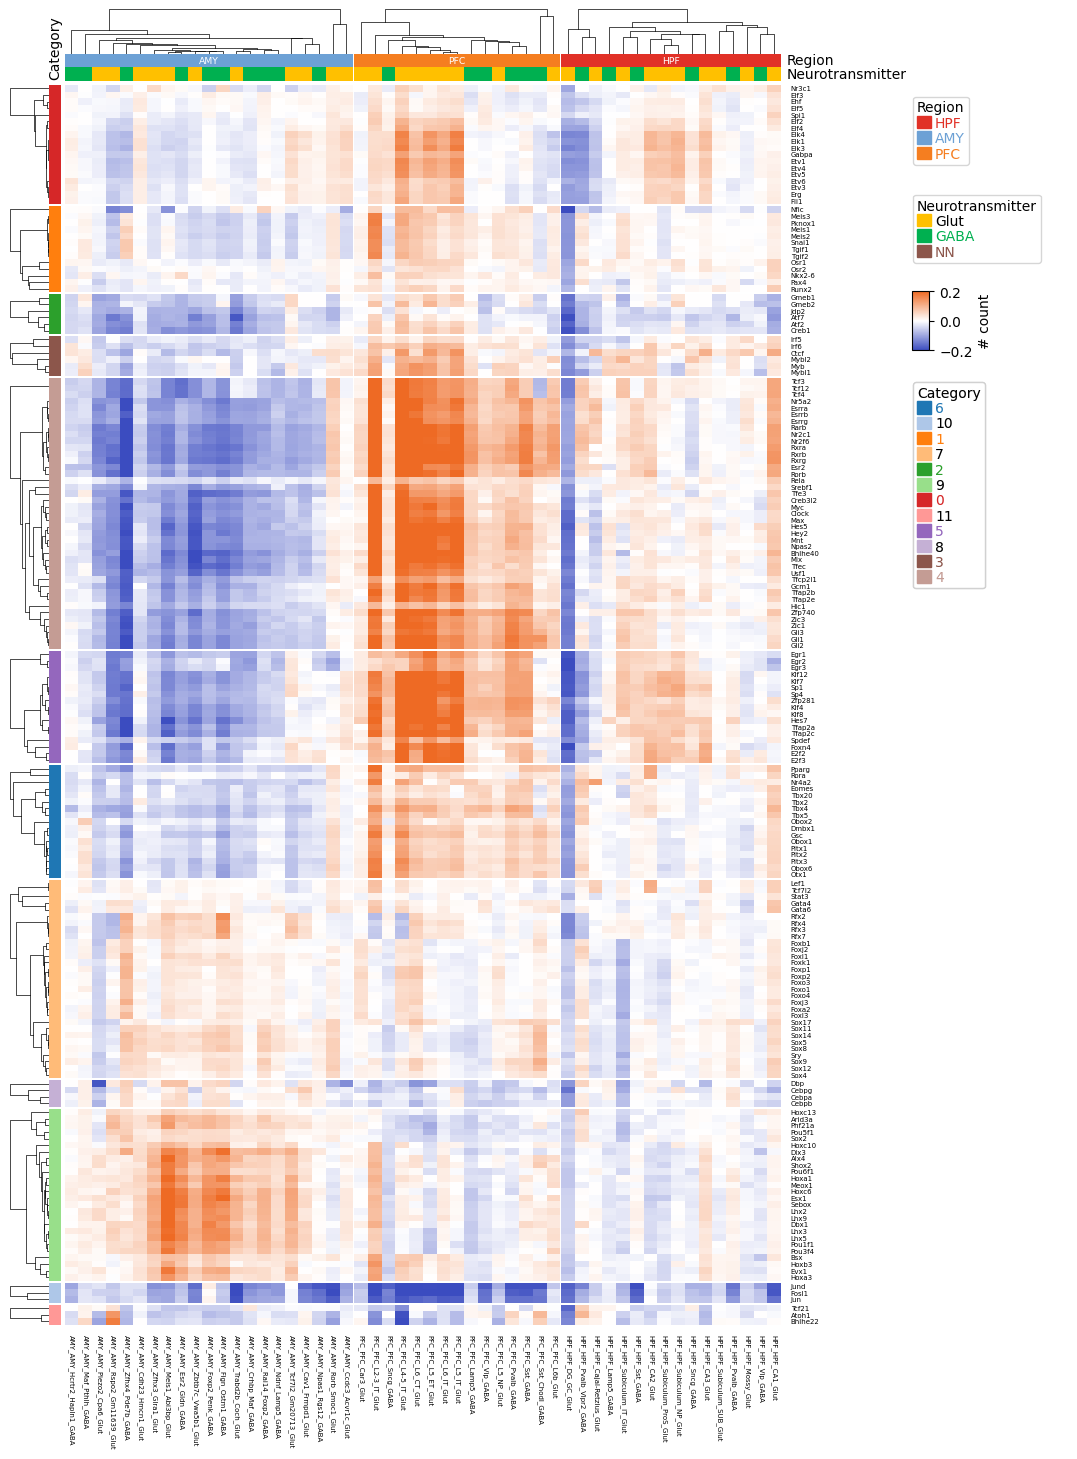

In [22]:
cm2 = draw_tf_heatmap(results[results.Neurotransmitter!='NN'],value_col="log2FC",figure_size=(10,15)
                     , clipping=0.2,save_fig=f'/home/junyichen/code/scmmd/figures/heatmaptobias_ANNO_{data_test}.pdf')


Checking columns...
Constant columns: []
Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..


/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


Starting plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 39.68888888888889 mm


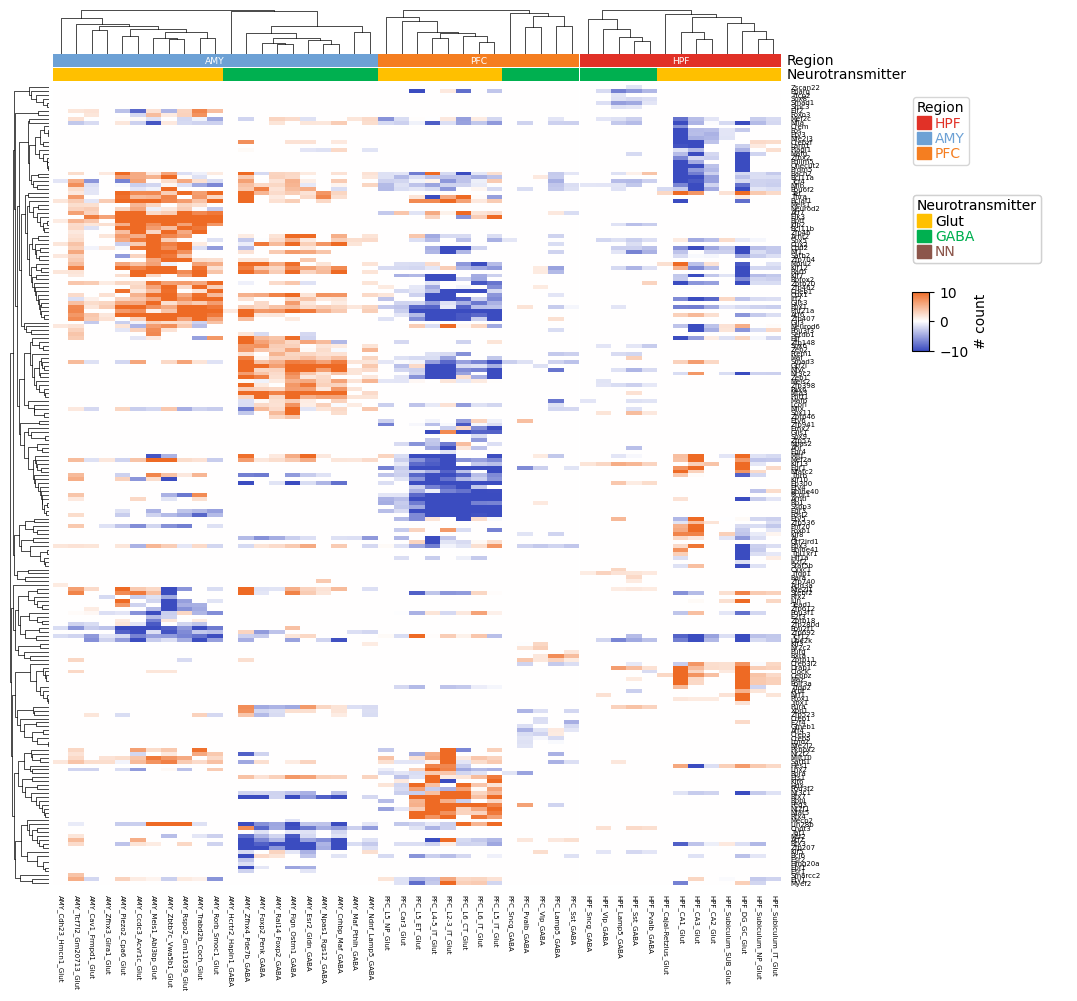

In [148]:
df_scenic = pd.read_csv(f'/data2st1/junyi/output/atac1112/scenic/scplus_region_based_AUC_filterd.csv', index_col=0)
df_scenic['Region Subclass'] = df_scenic['sample']
df_scenic['Direction'] = df_scenic['nlog10_p_val_adj'].apply(lambda x: 'Up' if x > 0 else 'Down')
df_scenic['ctname'] = df_scenic['Region Subclass']
df_scenic = add_columns(df_scenic)
# df_scenic['Category'] = df_scenic['TF'].map(tf_map)
# df_scenic['Category'].fillna('Other', inplace=True)
# df_scenic['Category']= df_scenic['Category'].astype('string')
cmsc = draw_tf_heatmap(df_scenic, value_col="nlog10_p_val_adj", clipping=10,figure_size=(10,10), save_fig=f'/home/junyichen/code/scmmd/figures/heatmapscenic_{data_test}.pdf')

In [56]:
import importlib
import utils
from utils import draw_tf_heatmap , annotate_region
# 修改了 my_module.py 后，重新加载
importlib.reload(utils)


<module 'utils' from '/home/junyichen/code/scmmd/utils.py'>

Checking columns...
Constant columns: []
Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..


/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


Starting plotting HeatmapAnnotations
Starting plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 39.68888888888889 mm


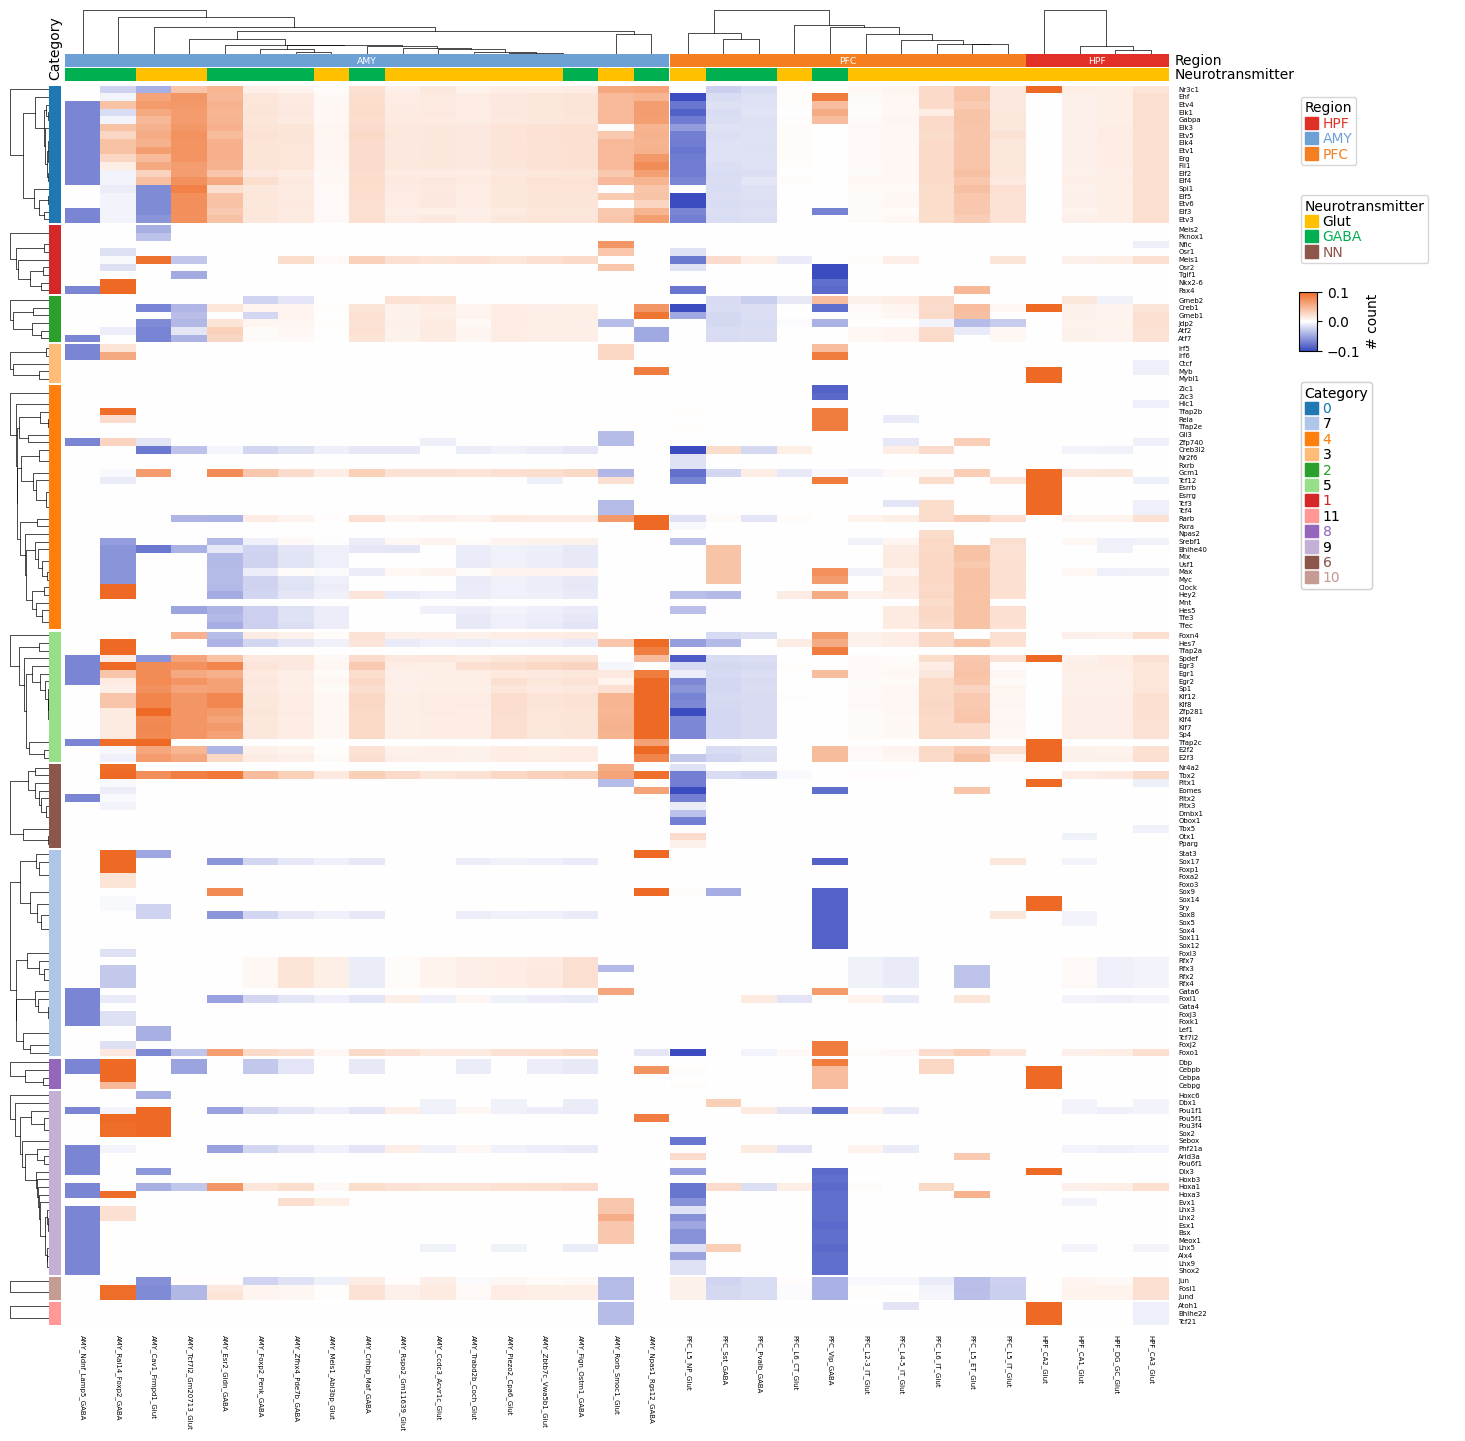

In [111]:
tf_map = dict(zip(df_annot_TF['TF'], df_annot_TF['Module']))
df_DAR_expanded_TF['Category'] = df_DAR_expanded_TF['TF'].map(tf_map)
df_DAR_expanded_TF['Category'].fillna('Other', inplace=True)
df_DAR_expanded_TF['Category']= df_DAR_expanded_TF['Category'].astype('string')
cmnDAR = draw_tf_heatmap(df_DAR_expanded_TF[(df_DAR_expanded_TF.Neurotransmitter!="NN") & (df_DAR_expanded_TF.Category!="Other")],value_col="log2FC",clipping=0.1,figure_size=(15,15))


Checking columns...
Constant columns: []
Starting plotting..
Starting calculating row orders..
Reordering rows..
Starting calculating col orders..
Reordering cols..
Plotting matrix..


/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/junyichen/anaconda3/envs/snapatac2/lib/python3.10/site-packages/PyComplexHeatmap/clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


Starting plotting HeatmapAnnotations
Starting plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 39.68888888888889 mm


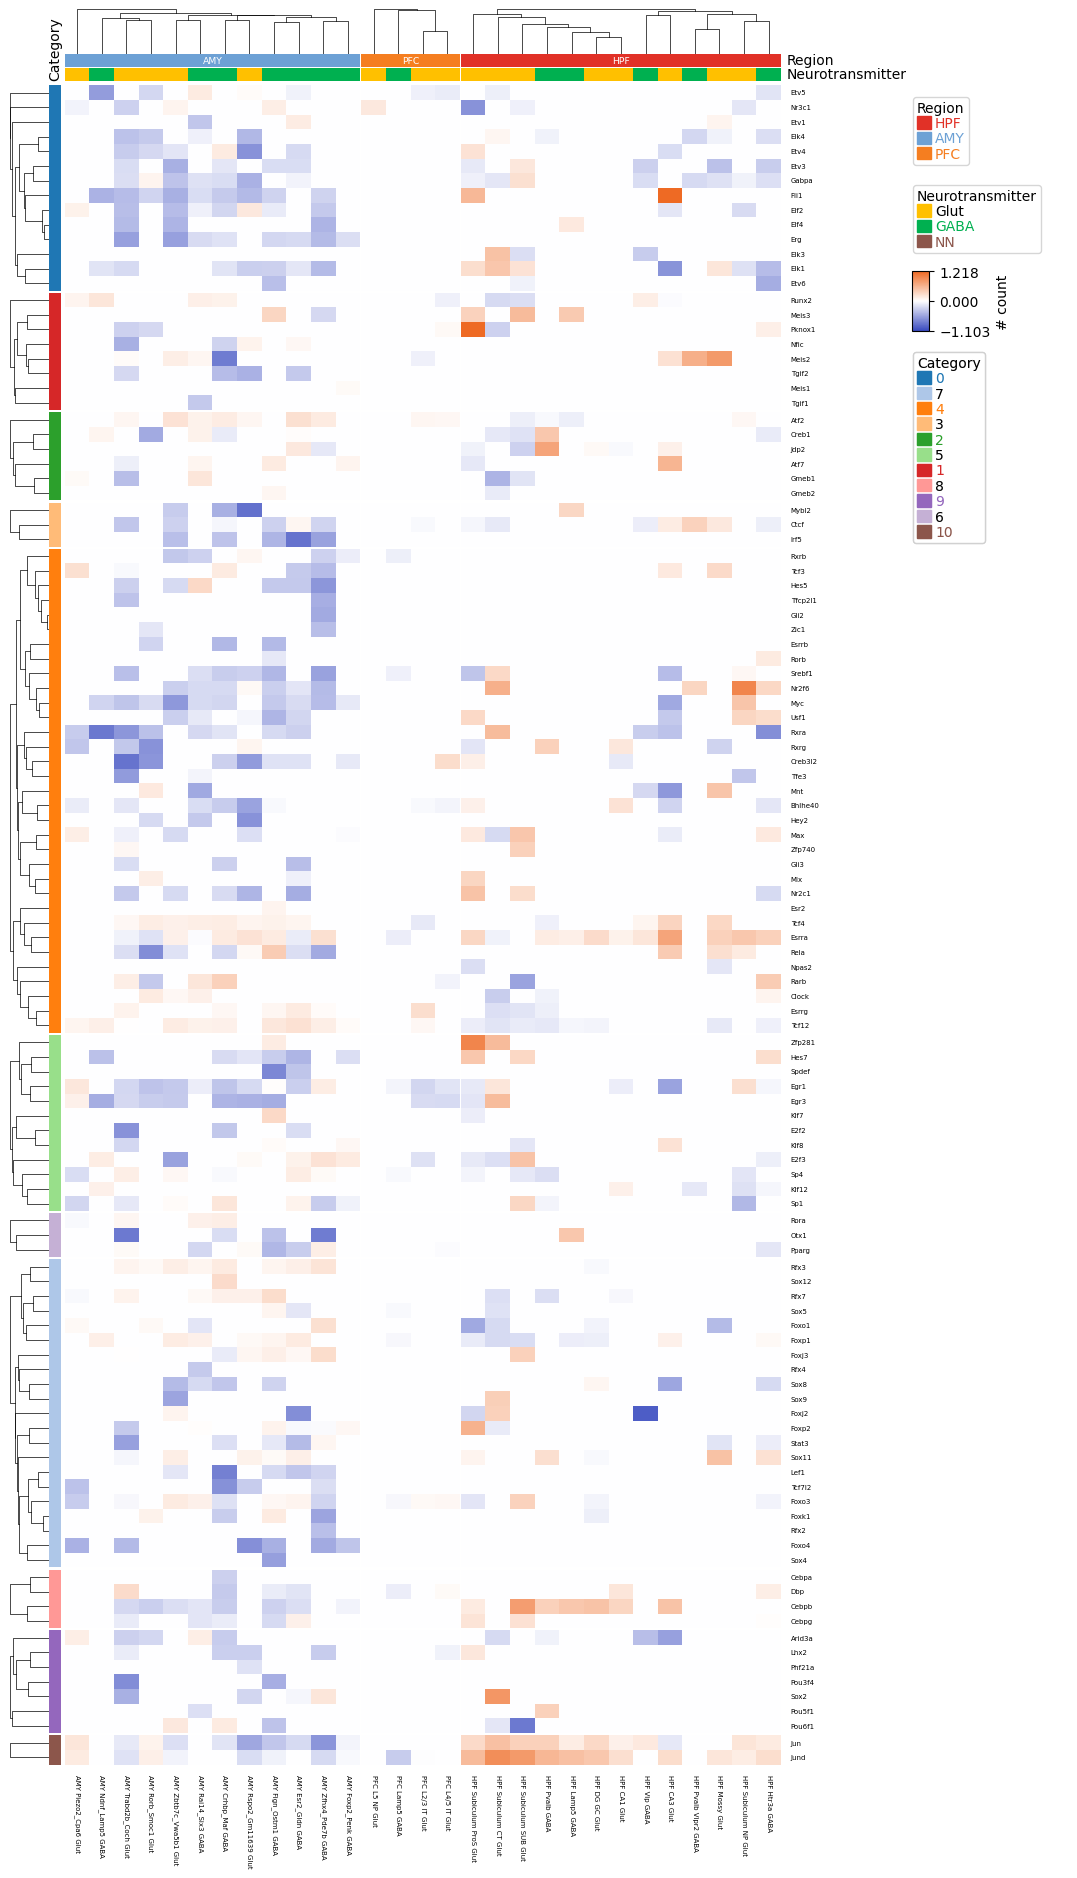

In [113]:
cmgene = draw_tf_heatmap(df_3R[(df_3R.Neurotransmitter!='NN') & (df_3R.Category!="Other")],value_col="log2FC",clipping=10)

In [ ]:
def draw_tf_heatmap_ordered(df,value_col="Regulation",row='TF',column='Region Subclass',
                            col_meta=['Region Subclass', 'Region', 'Neurotransmitter'],
                            clipping=10,row_order=None, col_order=None):
    df = df.copy()
    if clipping:
        df[value_col] = df[value_col].clip(-1*clipping,clipping)  
    
    if row_order is not None:
        df = df[df[row].isin(row_order)]
    if col_order is not None:
        df = df[df[column].isin(col_order)]
    # ============================
    # 1. 构建矩阵
    # ============================
    mat = df.pivot_table(
        index=row,
        columns=column,
        values=value_col,
        aggfunc="mean"
    ).fillna(0)
    print("Checking columns...")

    mat = mat.replace([np.inf, -np.inf], np.nan).fillna(0)
    mat = mat.astype(float)
    mat = mat.replace([np.inf, -np.inf], np.nan)
    mat = mat.fillna(0)
    mat = mat.apply(pd.to_numeric, errors="coerce").fillna(0)

    constant_cols = mat.columns[mat.apply(lambda x: x.nunique() <= 1)]
    print("Constant columns:", constant_cols.tolist())
    mat = mat.drop(columns=constant_cols)

    # # 2. Remove duplicate columns
    # mat_T = mat.T.drop_duplicates().T
    # removed_duplicates = set(mat.columns) - set(mat_T.columns)
    # print("Duplicate columns removed:", removed_duplicates)
    # mat = mat_T

    # 3. Final clean
    mat = mat.astype(float)
    assert np.isfinite(mat.values).all()

    # order the mat if row_order and col_order are provided
    if col_order is not None:
        # Only keep columns that exist
        col_order_filtered = [c for c in col_order if c in mat.columns]
        mat = mat[col_order_filtered]
    if row_order is not None:
        row_order_filtered = [r for r in row_order if r in mat.index]
        mat = mat.loc[row_order_filtered]
    # ============================
    # 2. 列注释 (Region + Neurotransmitter)
    # ============================
    col_meta = (
        df[["Region Subclass", "Region", "Neurotransmitter"]]
        .drop_duplicates()
        .set_index("Region Subclass")
        .loc[mat.columns]
    )

    # 按 region 排序列
    col_meta = col_meta.sort_values("Region")
    mat = mat[col_meta.index]
    region = col_meta["Region"]
    nt = col_meta["Neurotransmitter"]

    # ============================
    # 3. 行注释（可选：也可以不加）
    # ============================
    if "Category" in df.columns:
        row_meta = (
            df[["TF", "Category"]]
            .drop_duplicates()
            .set_index("TF")
            .loc[mat.index]
        )
        category = row_meta["Category"]
    else:
        category = None

    # ============================
    # 4. 创建顶部列注释
    # ============================
    col_ha = pch.HeatmapAnnotation(
        Region=pch.anno_simple(region, colors=region_colors, add_text=True),
        Neurotransmitter=pch.anno_simple(nt, colors=nt_colors, add_text=False),
        axis=1
    )
    # ============================
    # 5. 如果提供 Category，则加入左侧注释
    # ============================
    if category is not None:
        row_ha = pch.HeatmapAnnotation(
            Category=pch.anno_simple(category, add_text=False),
            axis=0
        )
    else:
        row_ha = None

    # ============================
    # 6. 颜色映射：蓝→白→橙，中心为0
    # ============================
    cmap = LinearSegmentedColormap.from_list(
        "blue_white_orange",
        ["#3B4CC0", "white", "#EE6A24"]
    )
    plt.figure(figsize=(10, 10))

    row_cluster = True if row_order is None else False
    col_cluster = True if col_order is None else False
    row_dendrogram = True if row_order is None else False
    col_dendrogram = True if col_order is None else False

    cm = pch.ClusterMapPlotter(
        data=mat,
        top_annotation=col_ha,
        left_annotation=row_ha,
        col_split=region,      # 按 Region 分面
        row_cluster=row_cluster,
        col_cluster=col_cluster,
        row_dendrogram=row_dendrogram,
        col_dendrogram=col_dendrogram,
        cmap=cmap,
        col_split_order = ['AMY','PFC','HPF'],
        center=0,
        show_rownames=True,
        show_colnames=True,
        label="# count",
        rasterized=True
    )
    plt.show()
    return cm

cm2 = draw_tf_heatmap_ordered(df_3R[df_3R.Neurotransmitter!='NN'],row_order=row_names,value_col="nlogp", clipping=20)

In [ ]:
df_3R

In [ ]:
cm = draw_tf_heatmap(df_3R[df_3R.Neurotransmitter!='NN'], value_col="nlogp", clipping=1)

In [ ]:
df_tobias_drop = df_tobias.sort_values(by='abs_change',ascending=False).drop_duplicates(subset=['TFID'], keep='first')

In [ ]:
df_tobias_drop = df_tobias_drop[~df_tobias_drop['name'].str.contains('meta')]

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# df = your TOBIAS BINDetect table
df_tobias_drop["neglog10_p"] = -np.log10(df_tobias_drop["MC_MW_pvalue"])

# ---- Top 20 UP (highest positive change) ----
top20_up = df_tobias_drop.nlargest(20, "MC_MW_change").copy()
top20_up["highlight"] = "up"

# ---- Top 20 DOWN (most negative change) ----
top20_down = df_tobias_drop.nsmallest(20, "MC_MW_change").copy()
top20_down["highlight"] = "down"

# ---- Combine top40 ----
top40 = pd.concat([top20_up, top20_down], axis=0)

# ---- Volcano plot ----
plt.figure(figsize=(10, 5))

# All background points (gray)
sns.scatterplot(
    data=df_tobias_drop,
    x="MC_MW_change",
    y="neglog10_p",
    color="lightgray",
    s=40
)

# Up 20 (red)
sns.scatterplot(
    data=top20_up,
    x="MC_MW_change",
    y="neglog10_p",
    color="red",
    s=80,
    edgecolor="black"
)

# Down 20 (blue)
sns.scatterplot(
    data=top20_down,
    x="MC_MW_change",
    y="neglog10_p",
    color="blue",
    s=80,
    edgecolor="black"
)

# ---- Add labels ----
for _, row in top40.iterrows():
    plt.text(
        row["MC_MW_change"],
        row["neglog10_p"],
        row["TF"],        # Your TF column name
        fontsize=8,
        ha="right",
        va="bottom"
    )

# ---- Axis + Style ----
plt.axvline(0, color="gray", linestyle="--")
plt.xlabel("Motif accessibility change (MC_MW_change)", fontsize=14)
plt.ylabel("-log10(p-value)", fontsize=14)
plt.title("Motif Accessibility Volcano Plot (Top20 Up / Top20 Down)", fontsize=16)
